In [1]:
from shared.main import * 
# subject_data = load_pickle("../../../analyses/lss_decision/subject_data_Schaefer100.pkl") 
subject_data = load_pickle("../../../analyses/lss_decision/subject_data_Tavares_and_striatum_spheres.pkl")
decision_trials = drop_neutral_trials(decision_trials)

<h1 align=center>V3</h1>

ROIs requested: 22 | already in results: 0 | to run: 22
Fast settings: classifiers=['logreg_l2'], Cs=(0.001, 0.1, 1.0, 10.0), k_grid=(300,), outer_splits=5, inner_splits=3, n_permutations=100, n_jobs=1, roi_n_jobs=-1


ROI classifier screen (dx):   0%|          | 0/22 [00:00<?, ?it/s]

permutations: logreg_l2:   0%|          | 0/100 [00:00<?, ?it/s]

permutations: logreg_l2:   0%|          | 0/100 [00:00<?, ?it/s]

permutations: logreg_l2:   0%|          | 0/100 [00:00<?, ?it/s]

...

permutations: logreg_l2:   0%|          | 0/100 [00:00<?, ?it/s]

permutations: logreg_l2:   0%|          | 0/100 [00:00<?, ?it/s]

permutations: logreg_l2:   0%|          | 0/100 [00:00<?, ?it/s]


Results written to:
  ../../../analyses/lss_decision/classification/dx_classifier_fast_l2_screen.csv
  ../../../analyses/lss_decision/classification/dx_classifier_fast_l2_predictions.csv
  ../../../analyses/lss_decision/classification/dx_classifier_fast_l2_folds.csv
  ../../../analyses/lss_decision/classification/dx_classifier_fast_l2_permutations.csv
  ../../../analyses/lss_decision/classification/dx_classifier_fast_l2_best_by_roi.csv
  ../../../analyses/lss_decision/classification/dx_classifier_fast_l2_best_overall.csv

Best ROI x classifier combinations:


,roi,classifier,n,n_class0,n_class1,n_features,bal_acc,perm_p_bal_acc,auc,perm_p_auc,accuracy,f1,best_C_mode,best_k_mode,inner_score_mean,error
0,Striatum-VSs-R,L2 logistic,61,33,28,104,0.636905,0.039604,0.705628,0.019802,0.639344,0.607143,0.001,300,0.551653,NaN
1,Striatum-VSi-R,L2 logistic,61,33,28,106,0.616342,0.069307,0.661255,0.039604,0.622951,0.566038,0.001,300,0.509392,NaN
2,Striatum-drP-R,L2 logistic,61,33,28,93,0.601190,0.099010,0.572511,0.168317,0.606557,0.555556,1.000,300,0.534854,NaN
3,HPC-R,L2 logistic,61,33,28,149,0.593074,0.168317,0.599567,0.178218,0.606557,0.500000,0.100,300,0.566865,NaN
4,Striatum-VSi-L,L2 logistic,61,33,28,90,0.586039,0.108911,0.627706,0.089109,0.590164,0.545455,0.001,300,0.604299,NaN
5,Striatum-DC-L,L2 logistic,61,33,28,94,0.561147,0.227723,0.534632,0.297030,0.557377,0.557377,0.100,300,0.586111,NaN
6,Striatum-vrP-R,L2 logistic,61,33,28,98,0.558442,0.267327,0.594156,0.227723,0.557377,0.542373,0.001,300,0.527844,NaN
7,dACC-L,L2 logistic,61,33,28,97,0.553030,0.346535,0.569264,0.316832,0.557377,0.509091,0.001,300,0.543585,NaN
8,HPC-L,L2 logistic,61,33,28,148,0.550325,0.267327,0.563853,0.237624,0.557377,0.490566,0.001,300,0.567063,NaN
9,dACC-R,L2 logistic,61,33,28,147,0.547619,0.257426,0.525974,0.366337,0.557377,0.470588,0.001,300,0.579828,NaN


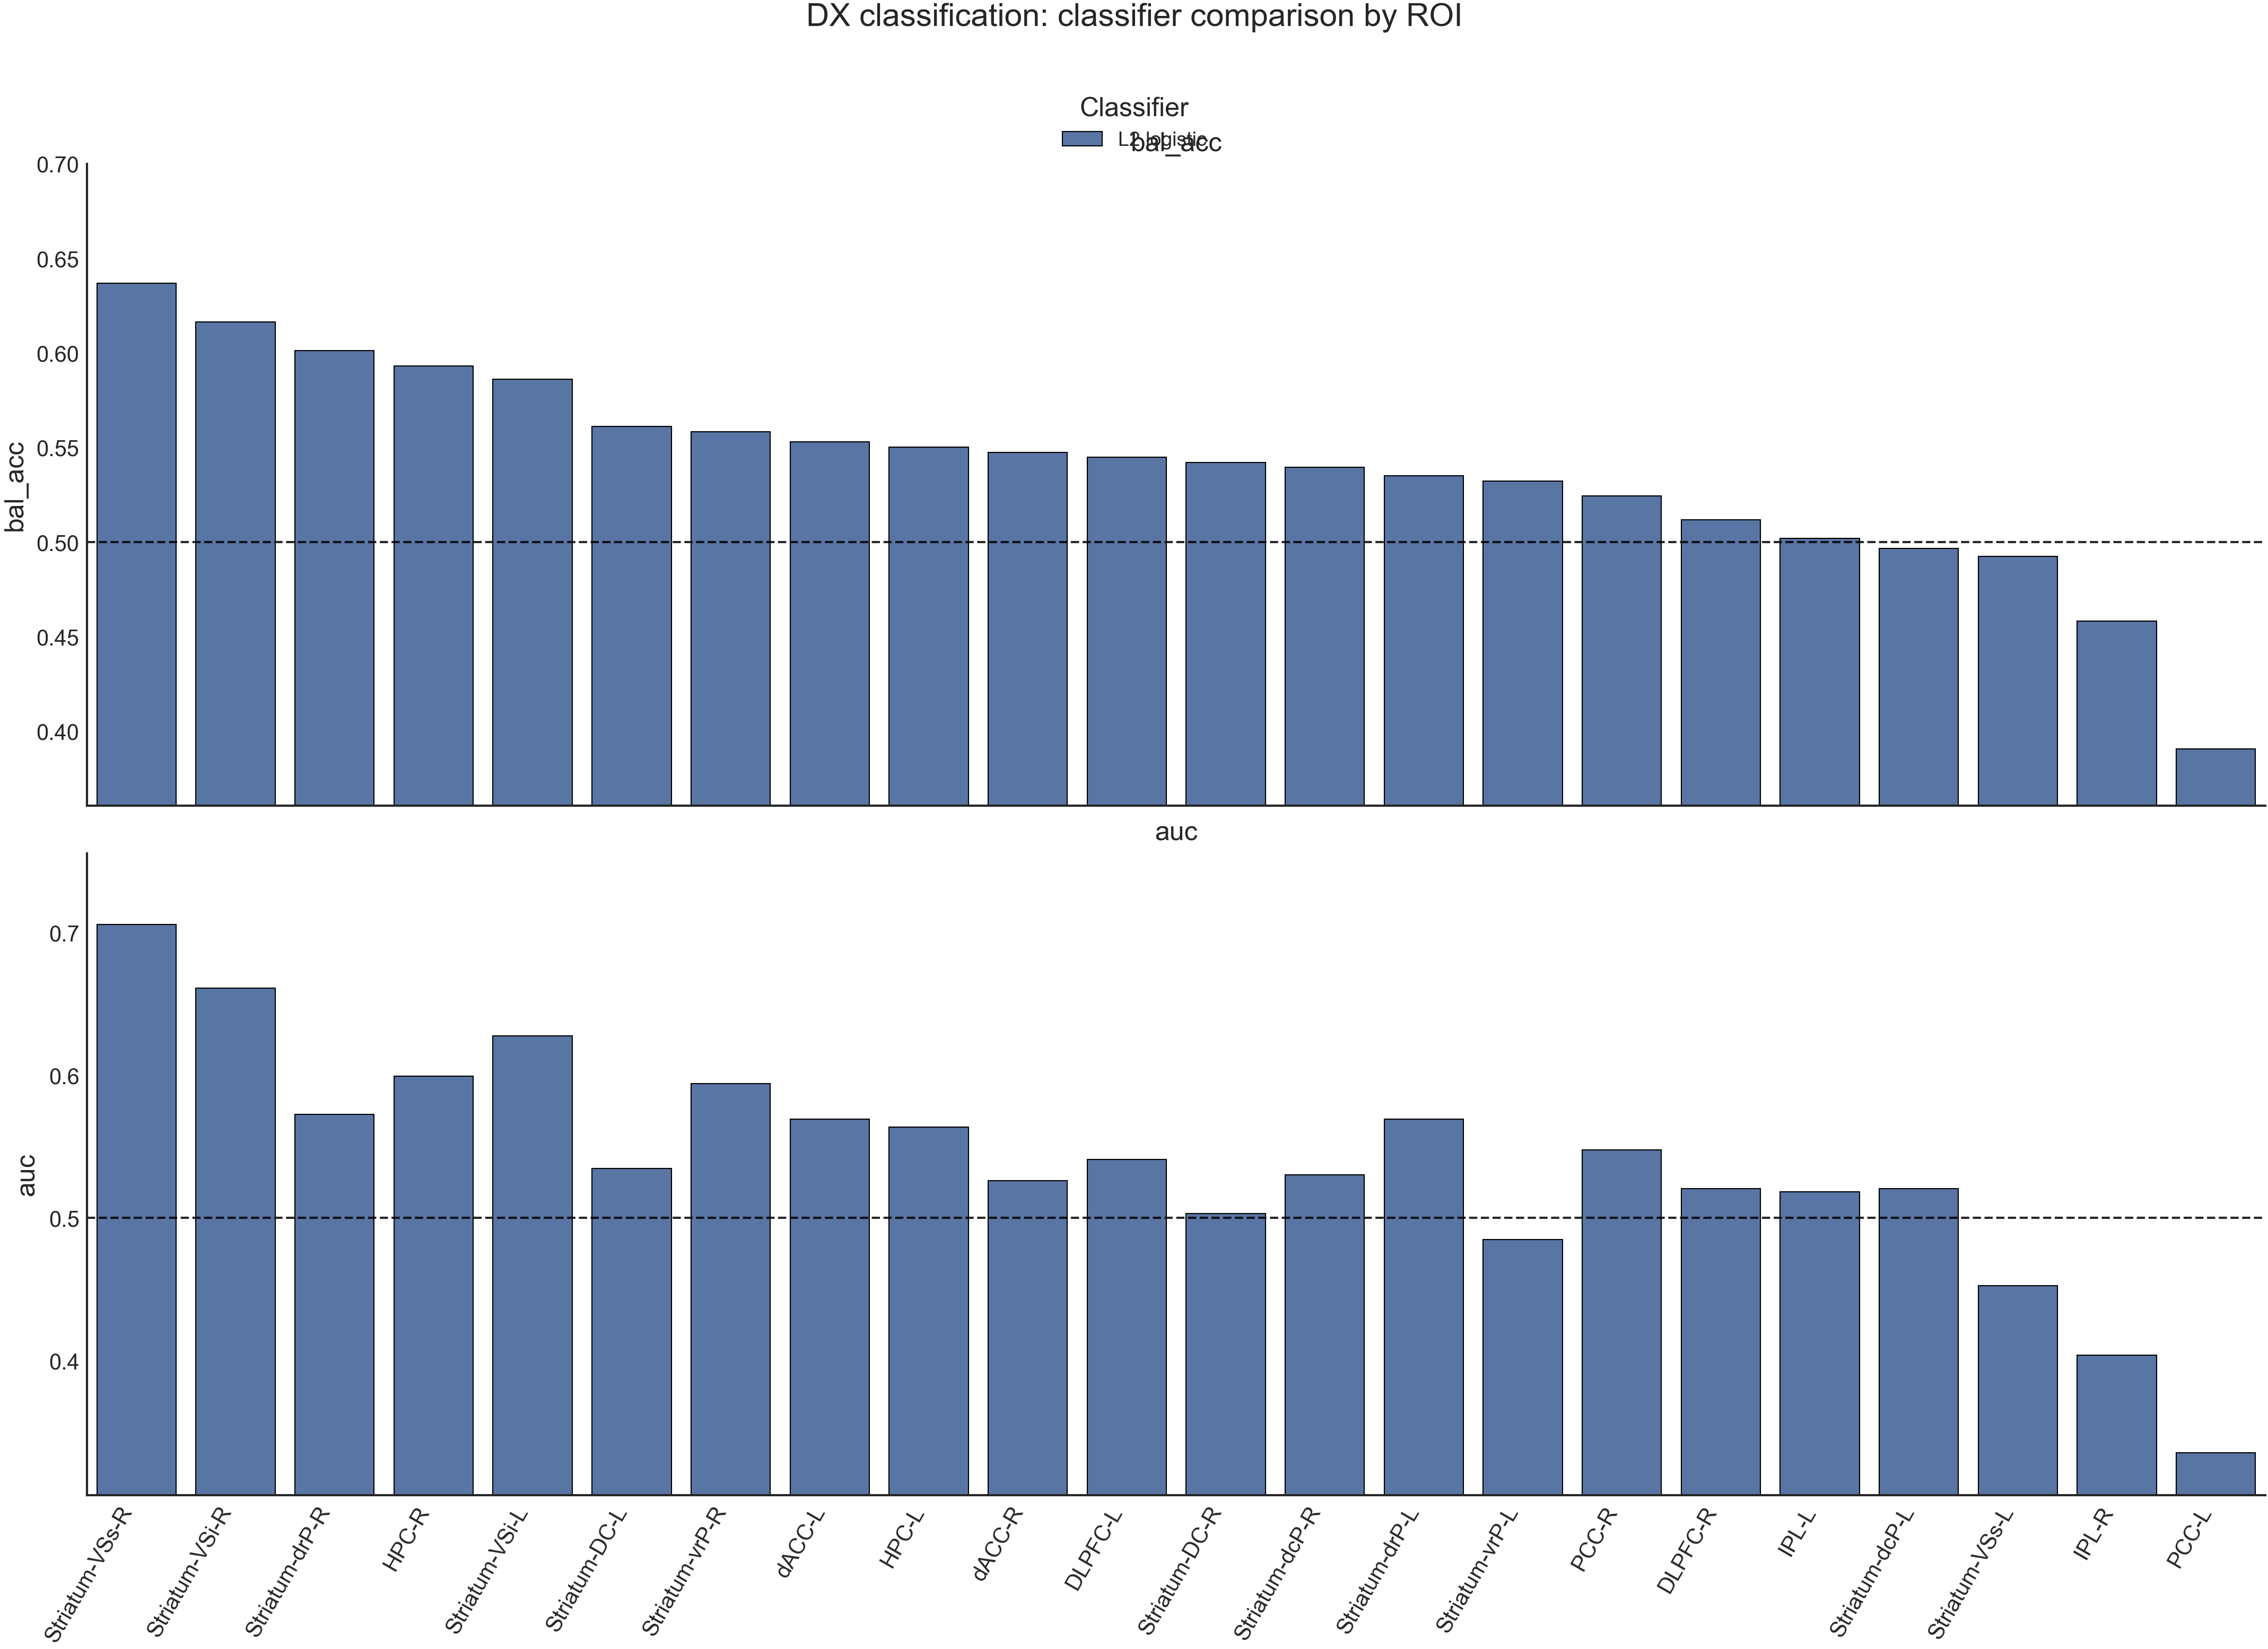

In [6]:
"""
Improved ROI-level DX classification screen.

Assumes the notebook/session has already created:
    subject_data : dict[sub_id] -> {"roi_betas": {roi_name: trials x voxels array}}
    incl_subs    : iterable of subject IDs
    data         : subject-level DataFrame with sub_id, dx, and covariates

Main changes from the original pasted block:
    - Writes results incrementally to RESULTS_DIR.
    - Skips ROIs already found in the screen results CSV.
    - Adds label-permutation tests for each ROI x classifier.
    - Uses a smaller, leakage-safe pipeline with optional foldwise covariate residualization,
      variance filtering, scaling, and leakage-safe univariate feature selection.
    - FAST SCREEN DEFAULTS: one model only (L2 logistic), a small C grid, fixed feature
      selection, fewer inner/outer CV folds, fewer permutations, and ROI-level parallelization.
"""

import json
import os
import time
import warnings
import zlib
from contextlib import nullcontext
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple
from joblib import Parallel, delayed
from tqdm.auto import tqdm
from threadpoolctl import threadpool_limits
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.exceptions import ConvergenceWarning
from sklearn.feature_selection import f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn")
warnings.filterwarnings("ignore", message="invalid value encountered")
warnings.filterwarnings("ignore", message="divide by zero encountered")
warnings.filterwarnings("ignore", message="Features .* are constant")

# ============================================================
# Configuration helpers
# ============================================================

CLASSIFIER_LABELS: Dict[str, str] = {
    "logreg_l2": "L2 logistic",
    "logreg_l1": "L1 logistic",
    "logreg_enet": "Elastic-net logistic",
    "svm_l2": "L2 SVM",
    "svm_l1": "L1 SVM",
}

NUMERIC_RESULT_COLS = [
    "n", "n_class0", "n_class1", "n_trials", "n_features", "n_model_features",
    "bal_acc", "auc", "accuracy", "f1", "precision", "recall",
    "best_C_mode", "best_C_mean", "best_l1_ratio_mode",
    "inner_score_mean", "perm_p_bal_acc", "perm_z_bal_acc",
    "perm_p_auc", "perm_z_auc", "n_permutations_done", "runtime_sec",
]

FAST_CLASSIFIERS: Tuple[str, ...] = ("logreg_l2",)
FAST_CS: Tuple[float, ...] = (0.001, 0.1, 1.0, 10.0)
FAST_K_GRID: Tuple[Any, ...] = (300,)  # SafeSelectKBest clamps to available features.
FAST_L1_RATIOS: Tuple[float, ...] = (0.5,)  # ignored for logreg_l2; kept for API compatibility.
FAST_OUTER_SPLITS = 5
FAST_INNER_SPLITS = 3
FAST_N_PERMUTATIONS = 100
FAST_MAX_ITER = 1000
FAST_TOL = 1e-3


def stable_seed(*items: Any) -> int:
    """Stable 32-bit seed from arbitrary objects."""
    payload = "|".join(map(str, items)).encode("utf-8")
    return zlib.crc32(payload) & 0xFFFFFFFF

def _json_dumps_safe(obj: Any) -> str:
    try:
        return json.dumps(obj, sort_keys=True)
    except Exception:
        return json.dumps(str(obj))

# ============================================================
# Outcome
# ============================================================

def make_y_binary(meta: pd.DataFrame, col: str = "dx") -> Tuple[np.ndarray, np.ndarray]:
    """Return binary 0/1 outcome plus validity mask."""
    y = pd.to_numeric(meta[col], errors="coerce").to_numpy(float)
    return y, np.isin(y, [0, 1])

# ============================================================
# Leakage-safe preprocessing transformers
# ============================================================

class MedianImputerKeepEmpty(BaseEstimator, TransformerMixin):
    """
    Median-impute columns while preserving exact feature count/order.
    Columns that are all-NaN in the training fold are filled with 0.
    """

    def fit(self, X, y=None):
        X = np.asarray(X, float)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            self.statistics_ = np.nanmedian(X, axis=0)
        self.statistics_ = np.asarray(self.statistics_, float)
        self.statistics_[~np.isfinite(self.statistics_)] = 0.0
        return self

    def transform(self, X):
        X = np.asarray(X, float).copy()
        bad = ~np.isfinite(X)
        if bad.any():
            rows, cols = np.where(bad)
            X[rows, cols] = self.statistics_[cols]
        return X

class ResidualizeFeatures(BaseEstimator, TransformerMixin):
    """
    Residualize voxel features with respect to covariates inside each CV fold.

    Input X is assumed to be [voxel_features..., covariates...].
    Output is only the residualized voxel-feature matrix.
    """

    def __init__(self, n_features: int, n_confounds: int = 0, keep_mean: bool = True, eps: float = 1e-12):
        self.n_features = n_features
        self.n_confounds = n_confounds
        self.keep_mean = keep_mean
        self.eps = eps

    def fit(self, X, y=None):
        X = np.asarray(X, float)
        F = X[:, : self.n_features]

        if self.n_confounds == 0:
            self.feature_mean_ = F.mean(axis=0)
            self.beta_ = None
            return self

        C = X[:, self.n_features : self.n_features + self.n_confounds]
        self.c_mean_ = C.mean(axis=0)
        self.c_sd_ = C.std(axis=0, ddof=1)
        self.c_sd_[~np.isfinite(self.c_sd_) | (self.c_sd_ < self.eps)] = 1.0

        Cz = (C - self.c_mean_) / self.c_sd_
        D = np.column_stack([np.ones(len(Cz)), Cz])

        self.feature_mean_ = F.mean(axis=0)
        self.beta_ = np.linalg.lstsq(D, F, rcond=None)[0]
        return self

    def transform(self, X):
        X = np.asarray(X, float)
        F = X[:, : self.n_features]

        if self.n_confounds == 0:
            return F

        C = X[:, self.n_features : self.n_features + self.n_confounds]
        Cz = (C - self.c_mean_) / self.c_sd_
        D = np.column_stack([np.ones(len(Cz)), Cz])

        resid = F - D @ self.beta_
        if self.keep_mean:
            resid = resid + self.feature_mean_
        return resid

class SafeVarianceThreshold(BaseEstimator, TransformerMixin):
    """Drop zero-variance features inside CV, but never return an empty matrix."""

    def __init__(self, threshold: float = 0.0):
        self.threshold = threshold

    def fit(self, X, y=None):
        X = np.asarray(X, float)
        if X.ndim != 2:
            raise ValueError(f"X must be 2D; got {X.shape}")
        var = np.nanvar(X, axis=0)
        support = np.isfinite(var) & (var > self.threshold)
        if not support.any():
            support = np.ones(X.shape[1], dtype=bool)
        self.support_ = support
        return self

    def transform(self, X):
        X = np.asarray(X, float)
        return X[:, self.support_]

class SafeSelectKBest(BaseEstimator, TransformerMixin):
    """
    Leakage-safe univariate feature selection.

    The usual SelectKBest errors if k > n_features. This clamps k to the number
    of available features in the training fold. k='all' leaves all features.
    """

    def __init__(self, k: Any = "all"):
        self.k = k

    def fit(self, X, y=None):
        X = np.asarray(X, float)
        n_features = X.shape[1]

        if self.k is None or str(self.k).lower() == "all":
            self.k_ = n_features
            self.support_ = np.ones(n_features, dtype=bool)
            return self

        k = int(self.k)
        k = max(1, min(k, n_features))
        self.k_ = k

        try:
            if y is None or len(np.unique(y)) < 2:
                scores = np.zeros(n_features, dtype=float)
            else:
                scores, _ = f_classif(X, y)
        except Exception:
            scores = np.zeros(n_features, dtype=float)

        scores = np.asarray(scores, float)
        scores[~np.isfinite(scores)] = -np.inf

        if np.all(scores == -np.inf):
            keep = np.arange(k)
        else:
            keep = np.argsort(scores)[::-1][:k]

        support = np.zeros(n_features, dtype=bool)
        support[keep] = True
        self.support_ = support
        return self

    def transform(self, X):
        X = np.asarray(X, float)
        return X[:, self.support_]

# ============================================================
# ROI feature construction
# ============================================================

def _maybe_drop_neutral_trials(betas: np.ndarray, drop_neutral: bool) -> np.ndarray:
    """Use the existing notebook drop_neutral_trials() function if requested."""
    if not drop_neutral:
        return betas
    if "drop_neutral_trials" not in globals():
        raise NameError("drop_neutral=True, but drop_neutral_trials() is not defined in this session.")
    return globals()["drop_neutral_trials"](betas)

def _summarize_trials(betas: np.ndarray, summaries: Sequence[str]) -> np.ndarray:
    parts = []
    summaries = tuple(s.lower() for s in summaries)

    if "mean" in summaries:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            parts.append(np.nanmean(betas, axis=0))

    if "std" in summaries:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            parts.append(np.nanstd(betas, axis=0, ddof=1))

    if not parts:
        raise ValueError("feature_summaries must include at least one of: 'mean', 'std'.")

    return np.concatenate(parts, axis=0) if len(parts) > 1 else parts[0]

def roi_trial_summary_features(
    roi: str,
    incl_subs: Sequence[Any],
    subject_data: Dict[Any, Dict[str, Any]],
    *,
    drop_neutral: bool = False,
    feature_summaries: Sequence[str] = ("mean",),
) -> Tuple[np.ndarray, List[Any], int, int]:
    """
    For each subject, summarize trials x voxels ROI betas into one feature vector.
    Default preserves the original behavior: mean across trials for each voxel.
    """
    feats, ids, n_trials_list = [], [], []

    for sid in incl_subs:
        try:
            b = subject_data[sid]["roi_betas"][roi]
        except KeyError:
            continue

        b = np.asarray(b, float)
        b = _maybe_drop_neutral_trials(b, drop_neutral=drop_neutral)

        if b.ndim != 2 or b.shape[0] == 0 or b.shape[1] == 0:
            continue

        feats.append(_summarize_trials(b, feature_summaries))
        ids.append(sid)
        n_trials_list.append(int(b.shape[0]))

    if len(feats) == 0:
        return np.empty((0, 0)), [], np.nan, np.nan

    n_features = np.array([f.shape[0] for f in feats])
    if not np.all(n_features == n_features[0]):
        counts = pd.Series(n_features).value_counts().head(10).to_dict()
        raise ValueError(
            f"{roi}: feature counts differ across subjects: {counts}. "
            "Voxel-wise classification requires aligned voxel columns. "
            "Re-extract ROI betas without subject-specific feature dropping, "
            "or keep/save a common voxel mask."
        )

    X = np.vstack(feats)
    n_trials = int(pd.Series(n_trials_list).mode().iloc[0])
    return X, ids, n_trials, int(n_features[0])

# ============================================================
# Modeling utilities
# ============================================================

def make_stratified_splits(y: np.ndarray, n_splits: int, random_state: int) -> Optional[List[Tuple[np.ndarray, np.ndarray]]]:
    y = np.asarray(y, int)
    classes, counts = np.unique(y, return_counts=True)
    if len(classes) < 2:
        return None
    k = int(min(n_splits, counts.min()))
    if k < 2:
        return None
    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)
    return list(cv.split(np.zeros(len(y)), y))

def make_classifier(
    classifier_name: str,
    *,
    class_weight: Optional[str] = "balanced",
    max_iter: int = 10000,
    tol: float = 1e-4,
):
    name = classifier_name.lower()

    if name == "logreg_l2":
        return LogisticRegression(
            penalty="l2",
            solver="liblinear",
            class_weight=class_weight,
            max_iter=max_iter,
            tol=tol,
        )

    if name == "logreg_l1":
        return LogisticRegression(
            penalty="l1",
            solver="liblinear",
            class_weight=class_weight,
            max_iter=max_iter,
            tol=tol,
        )

    if name == "logreg_enet":
        return LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            l1_ratio=0.5,
            class_weight=class_weight,
            max_iter=max_iter,
            tol=tol,
            n_jobs=1,
        )

    if name == "svm_l1":
        return LinearSVC(
            penalty="l1",
            loss="squared_hinge",
            dual=False,
            class_weight=class_weight,
            max_iter=max_iter,
            tol=tol,
        )

    if name == "svm_l2":
        return LinearSVC(
            penalty="l2",
            loss="squared_hinge",
            dual=True,
            class_weight=class_weight,
            max_iter=max_iter,
            tol=tol,
        )

    raise ValueError(f"Unknown classifier_name={classifier_name!r}. Use one of {list(CLASSIFIER_LABELS)}")

def make_pipeline_for_classifier(
    *,
    classifier_name: str,
    n_voxel_features: int,
    n_confounds: int = 0,
    residualize_confounds: bool = False,
    class_weight: Optional[str] = "balanced",
    max_iter: int = 10000,
    tol: float = 1e-4,
) -> Pipeline:
    steps: List[Tuple[str, Any]] = [("impute", MedianImputerKeepEmpty())]

    if residualize_confounds and n_confounds > 0:
        steps.append(
            (
                "resid",
                ResidualizeFeatures(
                    n_features=n_voxel_features,
                    n_confounds=n_confounds,
                    keep_mean=True,
                ),
            )
        )

    steps.extend(
        [
            ("var", SafeVarianceThreshold(threshold=0.0)),
            ("scale", StandardScaler()),
            ("select", SafeSelectKBest(k="all")),
            (
                "clf",
                make_classifier(
                    classifier_name,
                    class_weight=class_weight,
                    max_iter=max_iter,
                    tol=tol,
                ),
            ),
        ]
    )
    return Pipeline(steps)

def param_grid_for_classifier(
    classifier_name: str,
    *,
    Cs: Sequence[float],
    k_grid: Sequence[Any],
    l1_ratios: Sequence[float],
) -> Dict[str, List[Any]]:
    grid: Dict[str, List[Any]] = {}

    if k_grid is not None and len(k_grid) > 0:
        grid["select__k"] = list(k_grid)

    if classifier_name in {"logreg_l1", "logreg_l2", "logreg_enet", "svm_l1", "svm_l2"}:
        grid["clf__C"] = [float(c) for c in Cs]

    if classifier_name == "logreg_enet":
        grid["clf__l1_ratio"] = [float(r) for r in l1_ratios]

    return grid

def score_for_auc(estimator: Pipeline, X: np.ndarray) -> np.ndarray:
    """Continuous score for class 1, using probability when available."""
    clf = estimator.named_steps["clf"]

    try:
        proba = estimator.predict_proba(X)
        classes = list(clf.classes_)
        return proba[:, classes.index(1)]
    except Exception:
        pass

    try:
        score = estimator.decision_function(X)
        classes = list(clf.classes_)
        if np.ndim(score) == 1:
            if len(classes) == 2 and classes[1] == 1:
                return score
            if len(classes) == 2 and classes[0] == 1:
                return -score
            return score
        return score[:, classes.index(1)]
    except Exception:
        return estimator.predict(X).astype(float)

def classification_metrics(y: np.ndarray, y_pred: np.ndarray, y_score: np.ndarray) -> Dict[str, float]:
    y = np.asarray(y, int)
    y_pred = np.asarray(y_pred, int)
    y_score = np.asarray(y_score, float)

    ok = np.isfinite(y_pred) & np.isfinite(y_score)
    y, y_pred, y_score = y[ok], y_pred[ok], y_score[ok]

    if y.size == 0:
        return {"bal_acc": np.nan, "accuracy": np.nan, "f1": np.nan, "precision": np.nan, "recall": np.nan, "auc": np.nan}

    out = {
        "bal_acc": float(balanced_accuracy_score(y, y_pred)),
        "accuracy": float(accuracy_score(y, y_pred)),
        "f1": float(f1_score(y, y_pred, zero_division=0)),
        "precision": float(precision_score(y, y_pred, zero_division=0)),
        "recall": float(recall_score(y, y_pred, zero_division=0)),
    }

    try:
        out["auc"] = float(roc_auc_score(y, y_score)) if len(np.unique(y)) == 2 else np.nan
    except Exception:
        out["auc"] = np.nan

    return out

def nested_cv_predict(
    X: np.ndarray,
    y: np.ndarray,
    *,
    classifier_name: str,
    n_voxel_features: int,
    n_confounds: int = 0,
    residualize_confounds: bool = False,
    Cs: Sequence[float] = FAST_CS,
    k_grid: Sequence[Any] = FAST_K_GRID,
    l1_ratios: Sequence[float] = FAST_L1_RATIOS,
    outer_splits: int = FAST_OUTER_SPLITS,
    inner_splits: int = FAST_INNER_SPLITS,
    inner_scoring: str = "balanced_accuracy",
    random_state: int = 1,
    class_weight: Optional[str] = "balanced",
    max_iter: int = FAST_MAX_ITER,
    tol: float = FAST_TOL,
    n_jobs: int = 1,
    fixed_outer_splits: Optional[List[Tuple[np.ndarray, np.ndarray]]] = None,
    return_dfs: bool = True,
) -> Dict[str, Any]:
    """Nested CV with inner hyperparameter tuning and outer held-out predictions."""
    X = np.asarray(X, float)
    y = np.asarray(y, int)

    splits = fixed_outer_splits or make_stratified_splits(y, outer_splits, random_state)
    if splits is None:
        raise ValueError("Not enough subjects per class for outer CV.")

    y_pred = np.full(len(y), np.nan)
    y_score = np.full(len(y), np.nan)
    y_fold = np.full(len(y), np.nan)
    fold_rows = [] if return_dfs else None

    param_grid = param_grid_for_classifier(classifier_name, Cs=Cs, k_grid=k_grid, l1_ratios=l1_ratios)

    for fold, (train_idx, test_idx) in enumerate(splits, start=1):
        y_train = y[train_idx]

        # Rare in permutations: an outer training split can contain only one class.
        if len(np.unique(y_train)) < 2:
            majority = int(pd.Series(y_train).mode().iloc[0])
            y_pred[test_idx] = majority
            y_score[test_idx] = float(majority)
            y_fold[test_idx] = fold
            if return_dfs:
                fold_rows.append(
                    {
                        "classifier_key": classifier_name,
                        "classifier": CLASSIFIER_LABELS[classifier_name],
                        "fold": fold,
                        "n_train": int(len(train_idx)),
                        "n_test": int(len(test_idx)),
                        "best_params": _json_dumps_safe({"degenerate_train_split": True}),
                        "best_C": np.nan,
                        "best_k": np.nan,
                        "best_l1_ratio": np.nan,
                        "inner_score": np.nan,
                        "outer_bal_acc": float(balanced_accuracy_score(y[test_idx], y_pred[test_idx])),
                    }
                )
            continue

        inner_cv = make_stratified_splits(y_train, inner_splits, random_state + 1000 + fold)
        pipe = make_pipeline_for_classifier(
            classifier_name=classifier_name,
            n_voxel_features=n_voxel_features,
            n_confounds=n_confounds,
            residualize_confounds=residualize_confounds,
            class_weight=class_weight,
            max_iter=max_iter,
            tol=tol,
        )

        if inner_cv is None:
            # Small-sample fallback: fit a reasonable default without inner search.
            default_params = {}
            if "clf__C" in param_grid:
                default_params["clf__C"] = float(np.median(list(Cs)))
            if "select__k" in param_grid:
                default_params["select__k"] = "all"
            if classifier_name == "logreg_enet":
                default_params["clf__l1_ratio"] = 0.5
            est = pipe.set_params(**default_params)
            est.fit(X[train_idx], y_train)
            best_params = default_params
            inner_score = np.nan
        else:
            gs = GridSearchCV(
                estimator=pipe,
                param_grid=param_grid,
                scoring=inner_scoring,
                cv=inner_cv,
                n_jobs=n_jobs,
                refit=True,
                error_score=np.nan,
            )
            gs.fit(X[train_idx], y_train)
            est = gs.best_estimator_
            best_params = dict(gs.best_params_)
            inner_score = float(gs.best_score_) if np.isfinite(gs.best_score_) else np.nan

        pred = est.predict(X[test_idx])
        score = score_for_auc(est, X[test_idx])

        y_pred[test_idx] = pred
        y_score[test_idx] = score
        y_fold[test_idx] = fold

        if return_dfs:
            fold_rows.append(
                {
                    "classifier_key": classifier_name,
                    "classifier": CLASSIFIER_LABELS[classifier_name],
                    "fold": fold,
                    "n_train": int(len(train_idx)),
                    "n_test": int(len(test_idx)),
                    "best_params": _json_dumps_safe(best_params),
                    "best_C": float(best_params.get("clf__C", np.nan)),
                    "best_k": best_params.get("select__k", np.nan),
                    "best_l1_ratio": float(best_params.get("clf__l1_ratio", np.nan)),
                    "inner_score": inner_score,
                    "outer_bal_acc": float(balanced_accuracy_score(y[test_idx], pred)),
                }
            )

    if return_dfs:
        pred_df = pd.DataFrame(
            {
                "row": np.arange(len(y)),
                "fold": y_fold.astype(int),
                "y_true": y,
                "y_pred": y_pred.astype(int),
                "y_score": y_score,
            }
        )
        fold_df = pd.DataFrame(fold_rows)
    else:
        pred_df = pd.DataFrame()
        fold_df = pd.DataFrame()

    return {
        "metrics": classification_metrics(y, y_pred, y_score),
        "pred_df": pred_df,
        "fold_df": fold_df,
        "outer_splits": splits,
    }

def run_permutation_test(
    X: np.ndarray,
    y: np.ndarray,
    *,
    observed_metrics: Dict[str, float],
    classifier_name: str,
    n_voxel_features: int,
    n_confounds: int,
    residualize_confounds: bool,
    fixed_outer_splits: List[Tuple[np.ndarray, np.ndarray]],
    n_permutations: int = FAST_N_PERMUTATIONS,
    random_state: int = 1,
    show_progress: bool = True,
    perm_n_jobs: int = 1,
    **cv_kwargs: Any,
) -> Tuple[pd.DataFrame, Dict[str, float]]:
    """Label-permutation test. The full nested-CV procedure is rerun for every shuffled label vector."""
    if int(n_permutations) <= 0:
        return pd.DataFrame(), {
            "n_permutations_done": 0,
            "perm_p_bal_acc": np.nan,
            "perm_z_bal_acc": np.nan,
            "perm_p_auc": np.nan,
            "perm_z_auc": np.nan,
        }

    rng = np.random.default_rng(random_state)
    y_perms = [rng.permutation(y) for _ in range(int(n_permutations))]

    def _run_one_permutation(perm_i: int, y_perm_i: np.ndarray) -> Dict[str, Any]:
        try:
            res = nested_cv_predict(
                X,
                y_perm_i,
                classifier_name=classifier_name,
                n_voxel_features=n_voxel_features,
                n_confounds=n_confounds,
                residualize_confounds=residualize_confounds,
                fixed_outer_splits=fixed_outer_splits,
                random_state=random_state + 10000 + perm_i,
                return_dfs=False,
                **cv_kwargs,
            )
            return {"perm": int(perm_i + 1), **res["metrics"], "error": ""}
        except Exception as e:
            return {
                "perm": int(perm_i + 1), "bal_acc": np.nan, "auc": np.nan,
                "accuracy": np.nan, "f1": np.nan, "precision": np.nan,
                "recall": np.nan, "error": str(e),
            }

    iterator = list(enumerate(y_perms))
    if show_progress and int(perm_n_jobs) == 1:
        iterator = tqdm(iterator, desc=f"permutations: {classifier_name}", leave=False)

    if int(perm_n_jobs) == 1:
        rows = [_run_one_permutation(i, yp) for i, yp in iterator]
    else:
        # Threaded permutations share X/subject memory and avoid process-copy overhead.
        rows = Parallel(n_jobs=perm_n_jobs, prefer="threads")(
            delayed(_run_one_permutation)(i, yp) for i, yp in iterator
        )

    perm_df = pd.DataFrame(rows)
    summary: Dict[str, float] = {"n_permutations_done": int(len(perm_df))}

    for metric in ("bal_acc", "auc"):
        obs = observed_metrics.get(metric, np.nan)
        null = pd.to_numeric(perm_df.get(metric, pd.Series(dtype=float)), errors="coerce").to_numpy(float)
        null = null[np.isfinite(null)]
        if np.isfinite(obs) and null.size:
            summary[f"perm_p_{metric}"] = float((1.0 + np.sum(null >= obs)) / (1.0 + null.size))
            summary[f"perm_z_{metric}"] = float((obs - np.mean(null)) / (np.std(null, ddof=1) + 1e-12)) if null.size > 1 else np.nan
            summary[f"perm_null_mean_{metric}"] = float(np.mean(null))
            summary[f"perm_null_sd_{metric}"] = float(np.std(null, ddof=1)) if null.size > 1 else np.nan
        else:
            summary[f"perm_p_{metric}"] = np.nan
            summary[f"perm_z_{metric}"] = np.nan
            summary[f"perm_null_mean_{metric}"] = np.nan
            summary[f"perm_null_sd_{metric}"] = np.nan

    return perm_df, summary

# ============================================================
# File output / resume helpers
# ============================================================

def update_csv(path: Path, new_df: pd.DataFrame, key_cols: Optional[Sequence[str]] = None) -> pd.DataFrame:
    """Append/update a CSV atomically and de-duplicate on key_cols when provided."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    if new_df is None or new_df.empty:
        if path.exists():
            return pd.read_csv(path)
        return pd.DataFrame()

    new_df = new_df.copy()

    if path.exists() and path.stat().st_size > 0:
        try:
            old = pd.read_csv(path)
        except Exception:
            old = pd.DataFrame()
        combined = pd.concat([old, new_df], ignore_index=True, sort=False)
    else:
        combined = new_df

    if key_cols:
        keys = [c for c in key_cols if c in combined.columns]
        if keys:
            combined = combined.drop_duplicates(subset=keys, keep="last")

    tmp = path.with_suffix(path.suffix + ".tmp")
    combined.to_csv(tmp, index=False)
    os.replace(tmp, path)
    return combined

def completed_rois_from_screen_file(
    screen_file: Path,
    *,
    target_col: str,
    classifiers: Sequence[str],
    skip_by: str = "roi",
    only_successful: bool = False,
) -> set:
    """
    Determine which ROIs should be skipped.

    skip_by='roi'            -> skip ROI if it appears at all in the screen file.
    skip_by='roi_classifier' -> skip ROI only if all requested classifiers are present.
    """
    screen_file = Path(screen_file)
    if not screen_file.exists() or screen_file.stat().st_size == 0:
        return set()

    try:
        df = pd.read_csv(screen_file)
    except Exception:
        return set()

    if df.empty or "roi" not in df.columns:
        return set()
    if "target" in df.columns:
        df = df[df["target"].astype(str) == str(target_col)]
    if only_successful and "error" in df.columns:
        df = df[df["error"].fillna("").astype(str) == ""]

    if skip_by == "roi":
        return set(df["roi"].dropna().astype(str))

    if skip_by == "roi_classifier":
        completed = set()
        if "classifier_key" not in df.columns:
            return completed
        needed = set(map(str, classifiers))
        for roi, g in df.groupby("roi"):
            have = set(g["classifier_key"].dropna().astype(str))
            if needed.issubset(have):
                completed.add(str(roi))
        return completed

    raise ValueError("skip_by must be 'roi' or 'roi_classifier'.")

# ============================================================
# ROI runner
# ============================================================

def prepare_roi_model_data(
    roi: str,
    *,
    incl_subs: Sequence[Any],
    subject_data: Dict[Any, Dict[str, Any]],
    meta_df: pd.DataFrame,
    target_col: str = "dx",
    covariates: Optional[Sequence[str]] = None,
    covariate_mode: str = "residualize",  # {'residualize','append','none'}
    drop_neutral: bool = False,
    feature_summaries: Sequence[str] = ("mean",),
    min_n: int = 10,
) -> Dict[str, Any]:
    covariates = list(covariates or [])
    covariate_mode = str(covariate_mode).lower()
    if covariate_mode not in {"residualize", "append", "none"}:
        raise ValueError("covariate_mode must be 'residualize', 'append', or 'none'.")

    X_vox, ids, n_trials, n_features = roi_trial_summary_features(
        roi,
        incl_subs,
        subject_data,
        drop_neutral=drop_neutral,
        feature_summaries=feature_summaries,
    )

    if X_vox.shape[0] == 0:
        raise ValueError("No usable subjects.")

    meta = pd.DataFrame({"sub_id": ids}).merge(meta_df, on="sub_id", how="left")
    y, valid_y = make_y_binary(meta, col=target_col)

    use_covariates = bool(covariates) and covariate_mode in {"residualize", "append"}
    if use_covariates:
        missing_covs = [c for c in covariates if c not in meta.columns]
        if missing_covs:
            raise ValueError(f"Missing covariates in meta_df: {missing_covs}")
        cov_arr = meta[covariates].apply(pd.to_numeric, errors="coerce").to_numpy(float)
        valid_cov = np.isfinite(cov_arr).all(axis=1)
    else:
        cov_arr = np.empty((len(meta), 0), float)
        valid_cov = np.ones(len(meta), dtype=bool)

    valid_X = np.isfinite(X_vox).any(axis=1)
    valid = valid_y & valid_cov & valid_X

    meta_v = meta.loc[valid].reset_index(drop=True)
    X_vox_v = X_vox[valid]
    y_v = y[valid].astype(int)
    cov_v = cov_arr[valid]

    n0 = int((y_v == 0).sum())
    n1 = int((y_v == 1).sum())
    if len(y_v) < min_n or n0 < 2 or n1 < 2:
        raise ValueError("Too few usable subjects or too few subjects in one DX class.")

    if use_covariates and covariate_mode == "residualize":
        X_model = np.column_stack([X_vox_v, cov_v])
        n_confounds = len(covariates)
        residualize_confounds = True
    elif use_covariates and covariate_mode == "append":
        X_model = np.column_stack([X_vox_v, cov_v])
        n_confounds = 0
        residualize_confounds = False
    else:
        X_model = X_vox_v
        n_confounds = 0
        residualize_confounds = False

    return {
        "X_vox": X_vox_v,
        "X_model": X_model,
        "y": y_v,
        "meta": meta_v.assign(**{target_col: y_v}),
        "n_trials": int(n_trials) if np.isfinite(n_trials) else np.nan,
        "n_features": int(n_features) if np.isfinite(n_features) else np.nan,
        "n_model_features": int(X_model.shape[1]),
        "n_class0": n0,
        "n_class1": n1,
        "n_confounds": n_confounds,
        "residualize_confounds": residualize_confounds,
    }

def summarize_best_params(fold_df: pd.DataFrame) -> Dict[str, float]:
    out: Dict[str, float] = {}

    for col, out_mode, out_mean in [
        ("best_C", "best_C_mode", "best_C_mean"),
        ("inner_score", None, "inner_score_mean"),
    ]:
        vals = pd.to_numeric(fold_df.get(col, pd.Series(dtype=float)), errors="coerce").dropna().to_numpy(float)
        if vals.size:
            if out_mode:
                out[out_mode] = float(pd.Series(vals).mode().iloc[0])
            out[out_mean] = float(np.mean(vals))
        else:
            if out_mode:
                out[out_mode] = np.nan
            out[out_mean] = np.nan

    k_vals = fold_df.get("best_k", pd.Series(dtype=object)).dropna()
    out["best_k_mode"] = k_vals.mode().iloc[0] if len(k_vals) else np.nan

    l1_vals = pd.to_numeric(fold_df.get("best_l1_ratio", pd.Series(dtype=float)), errors="coerce").dropna().to_numpy(float)
    out["best_l1_ratio_mode"] = float(pd.Series(l1_vals).mode().iloc[0]) if l1_vals.size else np.nan

    return out

def run_one_roi(
    roi: str,
    *,
    incl_subs: Sequence[Any],
    subject_data: Dict[Any, Dict[str, Any]],
    meta_df: pd.DataFrame,
    target_col: str,
    classifiers: Sequence[str],
    covariates: Optional[Sequence[str]],
    covariate_mode: str,
    drop_neutral: bool,
    feature_summaries: Sequence[str],
    min_n: int,
    n_permutations: int,
    random_state: int,
    primary_metric: str = "bal_acc",
    permutation_random_state: Optional[int] = None,
    perm_n_jobs: int = 1,
    **cv_kwargs: Any,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    start = time.time()
    classifiers = list(classifiers)
    rows, pred_frames, fold_frames, perm_frames = [], [], [], []

    try:
        prepared = prepare_roi_model_data(
            roi,
            incl_subs=incl_subs,
            subject_data=subject_data,
            meta_df=meta_df,
            target_col=target_col,
            covariates=covariates,
            covariate_mode=covariate_mode,
            drop_neutral=drop_neutral,
            feature_summaries=feature_summaries,
            min_n=min_n,
        )
    except Exception as e:
        for clf_name in classifiers:
            rows.append(
                {
                    "roi": roi,
                    "classifier_key": clf_name,
                    "classifier": CLASSIFIER_LABELS.get(clf_name, clf_name),
                    "target": target_col,
                    "error": str(e),
                    "runtime_sec": round(time.time() - start, 3),
                }
            )
        return pd.DataFrame(rows), pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    X_model = prepared["X_model"]
    y = prepared["y"]
    meta_v = prepared["meta"]
    fixed_outer_splits = make_stratified_splits(y, cv_kwargs.get("outer_splits", 5), random_state)
    if fixed_outer_splits is None:
        err = "Not enough subjects per class for outer CV."
        for clf_name in classifiers:
            rows.append(
                {
                    "roi": roi,
                    "classifier_key": clf_name,
                    "classifier": CLASSIFIER_LABELS.get(clf_name, clf_name),
                    "target": target_col,
                    "n": int(len(y)),
                    "n_class0": prepared["n_class0"],
                    "n_class1": prepared["n_class1"],
                    "error": err,
                    "runtime_sec": round(time.time() - start, 3),
                }
            )
        return pd.DataFrame(rows), pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    for clf_name in classifiers:
        clf_start = time.time()
        try:
            cv_res = nested_cv_predict(
                X_model,
                y,
                classifier_name=clf_name,
                n_voxel_features=prepared["X_vox"].shape[1],
                n_confounds=prepared["n_confounds"],
                residualize_confounds=prepared["residualize_confounds"],
                fixed_outer_splits=fixed_outer_splits,
                random_state=random_state,
                **cv_kwargs,
            )
            metrics = cv_res["metrics"]
            fold_df = cv_res["fold_df"].copy()
            pred_df = cv_res["pred_df"].copy()

            perm_seed = permutation_random_state
            if perm_seed is None:
                perm_seed = stable_seed("perm", roi, clf_name, target_col, random_state)

            perm_df, perm_summary = run_permutation_test(
                X_model,
                y,
                observed_metrics=metrics,
                classifier_name=clf_name,
                n_voxel_features=prepared["X_vox"].shape[1],
                n_confounds=prepared["n_confounds"],
                residualize_confounds=prepared["residualize_confounds"],
                fixed_outer_splits=fixed_outer_splits,
                n_permutations=n_permutations,
                random_state=perm_seed,
                show_progress=bool(n_permutations) and int(perm_n_jobs) == 1,
                perm_n_jobs=perm_n_jobs,
                **cv_kwargs,
            )

            best_summary = summarize_best_params(fold_df)

            row = {
                "roi": roi,
                "classifier_key": clf_name,
                "classifier": CLASSIFIER_LABELS[clf_name],
                "target": target_col,
                "n": int(len(y)),
                "n_class0": prepared["n_class0"],
                "n_class1": prepared["n_class1"],
                "n_trials": prepared["n_trials"],
                "n_features": prepared["n_features"],
                "n_model_features": prepared["n_model_features"],
                **metrics,
                **best_summary,
                **perm_summary,
                "primary_metric": primary_metric,
                "covariates_used": ", ".join(covariates or []),
                "covariate_mode": covariate_mode,
                "residualized_covariates": bool(prepared["residualize_confounds"]),
                "feature_summaries": ",".join(feature_summaries),
                "n_permutations_requested": int(n_permutations),
                "error": "",
                "runtime_sec": round(time.time() - clf_start, 3),
            }
            rows.append(row)

            # Add identifiers without failing if nested_cv_predict already created some columns.
            for df in (pred_df, fold_df, perm_df):
                if not df.empty:
                    df["roi"] = roi
                    df["classifier_key"] = clf_name
                    df["classifier"] = CLASSIFIER_LABELS[clf_name]
                    df["target"] = target_col

            pred_df["sub_id"] = meta_v["sub_id"].to_numpy()
            front_pred = ["target", "roi", "classifier_key", "classifier", "sub_id"]
            pred_df = pred_df[front_pred + [c for c in pred_df.columns if c not in front_pred]]

            front_fold = ["target", "roi", "classifier_key", "classifier", "fold"]
            fold_df = fold_df[front_fold + [c for c in fold_df.columns if c not in front_fold]]

            if not perm_df.empty:
                front_perm = ["target", "roi", "classifier_key", "classifier", "perm"]
                perm_df = perm_df[front_perm + [c for c in perm_df.columns if c not in front_perm]]

            pred_frames.append(pred_df)
            fold_frames.append(fold_df)
            if not perm_df.empty:
                perm_frames.append(perm_df)

        except Exception as e:
            rows.append(
                {
                    "roi": roi,
                    "classifier_key": clf_name,
                    "classifier": CLASSIFIER_LABELS.get(clf_name, clf_name),
                    "target": target_col,
                    "n": int(len(y)),
                    "n_class0": prepared["n_class0"],
                    "n_class1": prepared["n_class1"],
                    "n_trials": prepared["n_trials"],
                    "n_features": prepared["n_features"],
                    "n_model_features": prepared["n_model_features"],
                    "covariates_used": ", ".join(covariates or []),
                    "covariate_mode": covariate_mode,
                    "feature_summaries": ",".join(feature_summaries),
                    "error": str(e),
                    "runtime_sec": round(time.time() - clf_start, 3),
                }
            )

    screen_df = pd.DataFrame(rows)
    pred_df_all = pd.concat(pred_frames, ignore_index=True) if pred_frames else pd.DataFrame()
    fold_df_all = pd.concat(fold_frames, ignore_index=True) if fold_frames else pd.DataFrame()
    perm_df_all = pd.concat(perm_frames, ignore_index=True) if perm_frames else pd.DataFrame()

    return screen_df, pred_df_all, fold_df_all, perm_df_all

def run_roi_dx_classifier_screen(
    rois: Sequence[str],
    *,
    incl_subs: Sequence[Any],
    subject_data: Dict[Any, Dict[str, Any]],
    meta_df: pd.DataFrame,
    results_dir: str | Path,
    result_prefix: str = "dx_classifier_fast_l2",
    target_col: str = "dx",
    classifiers: Sequence[str] = FAST_CLASSIFIERS,
    covariates: Optional[Sequence[str]] = None,
    covariate_mode: str = "residualize",
    drop_neutral: bool = False,
    feature_summaries: Sequence[str] = ("mean",),
    Cs: Sequence[float] = FAST_CS,
    k_grid: Sequence[Any] = FAST_K_GRID,
    l1_ratios: Sequence[float] = FAST_L1_RATIOS,
    outer_splits: int = FAST_OUTER_SPLITS,
    inner_splits: int = FAST_INNER_SPLITS,
    inner_scoring: str = "balanced_accuracy",
    primary_metric: str = "bal_acc",
    random_state: int = 1,
    class_weight: Optional[str] = "balanced",
    max_iter: int = FAST_MAX_ITER,
    tol: float = FAST_TOL,
    min_n: int = 10,
    n_jobs: int = 1,
    n_permutations: int = FAST_N_PERMUTATIONS,
    perm_n_jobs: int = 1,
    roi_n_jobs: int = -1,
    roi_prefer: str = "threads",
    blas_threads: int = 1,
    skip_existing: bool = True,
    skip_by: str = "roi",
    only_skip_successful: bool = False,
) -> Dict[str, pd.DataFrame]:
    """
    Main resumable ROI screen.

    Fast default behavior uses one L2-logistic classifier, a 3-value C grid,
    one fixed k value, 3x2 nested CV, and ROI-level threaded parallelism.

    Results written to:
        <result_prefix>_screen.csv
        <result_prefix>_predictions.csv
        <result_prefix>_folds.csv
        <result_prefix>_permutations.csv
        <result_prefix>_best_by_roi.csv
        <result_prefix>_best_overall.csv
        <result_prefix>_grouped_bars.png
    """
    results_dir = Path(results_dir)
    results_dir.mkdir(parents=True, exist_ok=True)

    classifiers = list(classifiers)
    unknown = [c for c in classifiers if c not in CLASSIFIER_LABELS]
    if unknown:
        raise ValueError(f"Unknown classifiers: {unknown}. Use one or more of {list(CLASSIFIER_LABELS)}")

    screen_file = results_dir / f"{result_prefix}_screen.csv"
    pred_file = results_dir / f"{result_prefix}_predictions.csv"
    fold_file = results_dir / f"{result_prefix}_folds.csv"
    perm_file = results_dir / f"{result_prefix}_permutations.csv"

    completed = set()
    if skip_existing:
        completed = completed_rois_from_screen_file(
            screen_file,
            target_col=target_col,
            classifiers=classifiers,
            skip_by=skip_by,
            only_successful=only_skip_successful,
        )

    rois = [str(r) for r in rois]
    todo_rois = [r for r in rois if r not in completed]
    print(f"ROIs requested: {len(rois)} | already in results: {len(completed)} | to run: {len(todo_rois)}")
    print(
        "Fast settings: "
        f"classifiers={classifiers}, Cs={tuple(Cs)}, k_grid={tuple(k_grid)}, "
        f"outer_splits={outer_splits}, inner_splits={inner_splits}, "
        f"n_permutations={n_permutations}, n_jobs={n_jobs}, roi_n_jobs={roi_n_jobs}"
    )

    cv_kwargs = dict(
        Cs=Cs,
        k_grid=k_grid,
        l1_ratios=l1_ratios,
        outer_splits=outer_splits,
        inner_splits=inner_splits,
        inner_scoring=inner_scoring,
        class_weight=class_weight,
        max_iter=max_iter,
        tol=tol,
        n_jobs=n_jobs,
    )

    def _run_and_package_roi(roi: str):
        return run_one_roi(
            roi,
            incl_subs=incl_subs,
            subject_data=subject_data,
            meta_df=meta_df,
            target_col=target_col,
            classifiers=classifiers,
            covariates=covariates,
            covariate_mode=covariate_mode,
            drop_neutral=drop_neutral,
            feature_summaries=feature_summaries,
            min_n=min_n,
            n_permutations=n_permutations,
            random_state=random_state,
            primary_metric=primary_metric,
            perm_n_jobs=perm_n_jobs,
            **cv_kwargs,
        )

    if int(roi_n_jobs) == 1 or len(todo_rois) <= 1:
        roi_results = [
            _run_and_package_roi(roi)
            for roi in tqdm(todo_rois, desc=f"ROI classifier screen ({target_col})")
        ]
    else:
        limit_ctx = (
            threadpool_limits(limits=int(blas_threads))
            if threadpool_limits is not None and blas_threads is not None
            else nullcontext()
        )
        with limit_ctx:
            roi_results = Parallel(n_jobs=roi_n_jobs, prefer=roi_prefer)(
                delayed(_run_and_package_roi)(roi)
                for roi in tqdm(todo_rois, desc=f"ROI classifier screen ({target_col})")
            )

    # Keep CSV writes in the parent process/thread to avoid write collisions.
    for screen_df, pred_df, fold_df, perm_df in roi_results:
        for c in NUMERIC_RESULT_COLS:
            if c in screen_df.columns:
                screen_df[c] = pd.to_numeric(screen_df[c], errors="coerce")

        update_csv(screen_file, screen_df, key_cols=["target", "roi", "classifier_key"])
        update_csv(pred_file, pred_df, key_cols=["target", "roi", "classifier_key", "sub_id"])
        update_csv(fold_file, fold_df, key_cols=["target", "roi", "classifier_key", "fold"])
        update_csv(perm_file, perm_df, key_cols=["target", "roi", "classifier_key", "perm"])

    outputs = refresh_summary_outputs(
        results_dir=results_dir,
        result_prefix=result_prefix,
        primary_metric=primary_metric,
    )

    # Add file paths for convenience.
    outputs["screen_file"] = pd.DataFrame({"path": [str(screen_file)]})
    outputs["prediction_file"] = pd.DataFrame({"path": [str(pred_file)]})
    outputs["fold_file"] = pd.DataFrame({"path": [str(fold_file)]})
    outputs["permutation_file"] = pd.DataFrame({"path": [str(perm_file)]})
    return outputs

# ============================================================
# Summaries and plots
# ============================================================

def refresh_summary_outputs(
    *,
    results_dir: str | Path,
    result_prefix: str = "dx_classifier",
    primary_metric: str = "bal_acc",
    top_n_plot: int = 25,
) -> Dict[str, pd.DataFrame]:
    results_dir = Path(results_dir)
    screen_file = results_dir / f"{result_prefix}_screen.csv"
    if not screen_file.exists() or screen_file.stat().st_size == 0:
        return {"screen_df": pd.DataFrame(), "best_by_roi": pd.DataFrame(), "best_overall": pd.DataFrame()}

    screen_df = pd.read_csv(screen_file)
    for c in NUMERIC_RESULT_COLS:
        if c in screen_df.columns:
            screen_df[c] = pd.to_numeric(screen_df[c], errors="coerce")

    ok = screen_df.copy()
    if "error" in ok.columns:
        ok = ok[ok["error"].fillna("").astype(str) == ""].copy()

    if ok.empty:
        return {"screen_df": screen_df, "best_by_roi": pd.DataFrame(), "best_overall": pd.DataFrame()}

    sort_cols = [c for c in [primary_metric, "auc"] if c in ok.columns]
    best_overall = ok.sort_values(sort_cols, ascending=[False] * len(sort_cols), na_position="last").reset_index(drop=True)

    best_by_roi = (
        ok.sort_values(["roi", *sort_cols], ascending=[True] + [False] * len(sort_cols), na_position="last")
        .groupby("roi", as_index=False)
        .head(1)
        .sort_values(sort_cols, ascending=[False] * len(sort_cols), na_position="last")
        .reset_index(drop=True)
    )

    best_overall.to_csv(results_dir / f"{result_prefix}_best_overall.csv", index=False)
    best_by_roi.to_csv(results_dir / f"{result_prefix}_best_by_roi.csv", index=False)

    try:
        fig, axes, plot_df = plot_roi_classifier_grouped_bars(
            ok,
            metrics=("bal_acc", "auc"),
            top_n=top_n_plot,
            sort_metric=primary_metric,
            title="DX classification: classifier comparison by ROI",
            save=results_dir / f"{result_prefix}_grouped_bars.png",
        )
        # Also save a vector version.
        fig.savefig(results_dir / f"{result_prefix}_grouped_bars.svg", bbox_inches="tight")
    except Exception as e:
        print(f"Plotting failed: {e}")
        plot_df = pd.DataFrame()

    return {"screen_df": screen_df, "best_by_roi": best_by_roi, "best_overall": best_overall}

def plot_roi_classifier_grouped_bars(
    roi_clf_df: pd.DataFrame,
    *,
    metrics: Sequence[str] = ("bal_acc", "auc"),
    top_n: Optional[int] = 25,
    sort_metric: str = "bal_acc",
    classifier_order: Sequence[str] = ("L2 logistic", "Elastic-net logistic", "L1 logistic", "L1 SVM", "L2 SVM"),
    chance_lines: Optional[Dict[str, float]] = None,
    figsize: Optional[Tuple[float, float]] = None,
    title: str = "DX classifier comparison by ROI",
    save: Optional[str | Path] = None,
):
    import matplotlib.pyplot as plt
    import seaborn as sns

    if chance_lines is None:
        chance_lines = {"bal_acc": 0.50, "auc": 0.50, "accuracy": 0.50}

    df = roi_clf_df.copy()
    if "error" in df.columns:
        df = df[df["error"].fillna("").astype(str) == ""].copy()

    metrics = [m for m in metrics if m in df.columns]
    if len(metrics) == 0:
        raise ValueError("None of the requested metrics are present in roi_clf_df.")

    for c in set(metrics + [sort_metric]):
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    classifier_order = [c for c in classifier_order if c in df["classifier"].unique()]
    if len(classifier_order) == 0:
        classifier_order = list(pd.unique(df["classifier"]))

    roi_rank = df.groupby("roi", as_index=True)[sort_metric].max().sort_values(ascending=False)
    rois = roi_rank.index.tolist()
    if top_n is not None:
        rois = rois[:top_n]

    plot_df = df[df["roi"].isin(rois)].copy()
    plot_df["roi"] = pd.Categorical(plot_df["roi"], categories=rois, ordered=True)
    plot_df["classifier"] = pd.Categorical(plot_df["classifier"], categories=classifier_order, ordered=True)
    plot_df = plot_df.sort_values(["roi", "classifier"])

    if figsize is None:
        figsize = (max(12, 0.65 * len(rois)), 4.8 * len(metrics))

    fig, axes = plt.subplots(len(metrics), 1, figsize=figsize, sharex=True, constrained_layout=True)
    if len(metrics) == 1:
        axes = [axes]

    for ax, metric in zip(axes, metrics):
        try:
            sns.barplot(
                data=plot_df,
                x="roi",
                y=metric,
                hue="classifier",
                order=rois,
                hue_order=classifier_order,
                errorbar=None,
                edgecolor="black",
                linewidth=0.5,
                ax=ax,
            )
        except TypeError:  # older seaborn
            sns.barplot(
                data=plot_df,
                x="roi",
                y=metric,
                hue="classifier",
                order=rois,
                hue_order=classifier_order,
                ci=None,
                edgecolor="black",
                linewidth=0.5,
                ax=ax,
            )

        if metric in chance_lines:
            ax.axhline(chance_lines[metric], color="black", linestyle="--", linewidth=1, alpha=0.85)

        vals = plot_df[metric].to_numpy(float)
        vals = vals[np.isfinite(vals)]
        if vals.size:
            ymin = min(0.45, float(vals.min()) - 0.03)
            ymax = max(0.70, float(vals.max()) + 0.05)
            ax.set_ylim(ymin, ymax)

        ax.set_title(metric)
        ax.set_ylabel(metric)
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=60)
        for tick in ax.get_xticklabels():
            tick.set_ha("right")

    handles, labels = axes[0].get_legend_handles_labels()
    for ax in axes:
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()

    fig.legend(
        handles,
        labels,
        title="Classifier",
        loc="upper center",
        bbox_to_anchor=(0.5, 1.03),
        ncol=max(1, len(labels)),
        frameon=False,
    )
    fig.suptitle(title, y=1.08)

    if save is not None:
        Path(save).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save, dpi=300, bbox_inches="tight")

    return fig, axes, plot_df

# ============================================================
# Run block for notebook use
# ============================================================

RESULTS_DIR = Path("../../../analyses/lss_decision/classification")
RESULT_PREFIX = "dx_classifier_fast_l2"
N_PERMUTATIONS = FAST_N_PERMUTATIONS

if all(name in globals() for name in ["subject_data", "incl_subs", "data"]):
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    _example_sid = next(iter(subject_data))
    ROIS = list(subject_data[_example_sid]["roi_betas"].keys())

    dx_outputs = run_roi_dx_classifier_screen(
        ROIS,
        incl_subs=incl_subs,
        subject_data=subject_data,
        meta_df=data,
        results_dir=RESULTS_DIR,
        result_prefix=RESULT_PREFIX,
        target_col="dx",
        classifiers=FAST_CLASSIFIERS,
        covariates=["sex", "fd_mean", "memory_mean"],
        covariate_mode="residualize",  # use 'append' for pure prediction including covariates
        drop_neutral=False,
        feature_summaries=("mean",),   # try ('mean','std') only if you want larger feature sets
        Cs=FAST_CS,
        k_grid=FAST_K_GRID,
        l1_ratios=FAST_L1_RATIOS,
        outer_splits=FAST_OUTER_SPLITS,
        inner_splits=FAST_INNER_SPLITS,
        inner_scoring="balanced_accuracy",
        primary_metric="bal_acc",
        random_state=1,
        class_weight="balanced",
        max_iter=FAST_MAX_ITER,
        tol=FAST_TOL,
        min_n=10,
        n_jobs=1,                 # keep inner GridSearch serial; parallelize across ROIs instead
        n_permutations=N_PERMUTATIONS,
        perm_n_jobs=1,            # set >1 only if roi_n_jobs=1
        roi_n_jobs=-1,            # ROI-level threading shares subject_data without process-copying it
        roi_prefer="threads",
        blas_threads=1,
        skip_existing=True,
        skip_by="roi",                 # exactly: if ROI appears in screen CSV, skip it
        only_skip_successful=False,
    )

    roi_clf_df = dx_outputs["screen_df"]
    best_by_roi = dx_outputs["best_by_roi"]
    best_overall = dx_outputs["best_overall"]

    print("\nResults written to:")
    print(f"  {RESULTS_DIR / (RESULT_PREFIX + '_screen.csv')}")
    print(f"  {RESULTS_DIR / (RESULT_PREFIX + '_predictions.csv')}")
    print(f"  {RESULTS_DIR / (RESULT_PREFIX + '_folds.csv')}")
    print(f"  {RESULTS_DIR / (RESULT_PREFIX + '_permutations.csv')}")
    print(f"  {RESULTS_DIR / (RESULT_PREFIX + '_best_by_roi.csv')}")
    print(f"  {RESULTS_DIR / (RESULT_PREFIX + '_best_overall.csv')}")

    if not best_overall.empty:
        cols = [
            "roi", "classifier", "n", "n_class0", "n_class1", "n_features",
            "bal_acc", "perm_p_bal_acc", "auc", "perm_p_auc", "accuracy", "f1",
            "best_C_mode", "best_k_mode", "inner_score_mean", "error",
        ]
        cols = [c for c in cols if c in best_overall.columns]
        print("\nBest ROI x classifier combinations:")
        try:
            display(best_overall[cols].head(20))
        except NameError:
            print(best_overall[cols].head(20).to_string(index=False))
else:
    print(
        "Loaded improved ROI classification functions. Define subject_data, incl_subs, and data, "
        "then call run_roi_dx_classifier_screen(...)."
    )


ROIs requested: 22 | already in results: 0 | to run: 22
Fast CTQ settings: model_keys=('ridge',), ridge_alphas=(0.1, 10.0, 1000.0), k_grid=(300,), outer=3, inner=2, permutations=10, n_jobs=1, perm_n_jobs=1, roi_n_jobs=-1


CTQ ROI regression (ctq_score):   0%|          | 0/22 [00:00<?, ?it/s]


Results written to:
  config: ../../../analyses/lss_decision/ctq_regression/ctq_fast_ridge_simple_config.json
  screen: ../../../analyses/lss_decision/ctq_regression/ctq_fast_ridge_simple_screen.csv
  predictions: ../../../analyses/lss_decision/ctq_regression/ctq_fast_ridge_simple_predictions.csv
  folds: ../../../analyses/lss_decision/ctq_regression/ctq_fast_ridge_simple_folds.csv
  permutations: ../../../analyses/lss_decision/ctq_regression/ctq_fast_ridge_simple_permutations.csv
  best_by_roi: ../../../analyses/lss_decision/ctq_regression/ctq_fast_ridge_simple_best_by_roi.csv
  best_overall: ../../../analyses/lss_decision/ctq_regression/ctq_fast_ridge_simple_best_overall.csv
  bar_png: ../../../analyses/lss_decision/ctq_regression/ctq_fast_ridge_simple_roi_barplot.png
  bar_svg: ../../../analyses/lss_decision/ctq_regression/ctq_fast_ridge_simple_roi_barplot.svg
  scatter_png: ../../../analyses/lss_decision/ctq_regression/ctq_fast_ridge_simple_best_scatter.png
  scatter_svg: ../../..

,roi,model,n,n_trials,n_features,r,perm_p_r,perm_fdr_r,spearman,r2,mae,rmse,best_alpha_mode,best_k_mode,inner_score_mean,error
0,PCC-R,Ridge,61,63,1953,0.231709,0.090909,0.857143,0.180751,0.051428,14.928505,18.678304,1000.0,300,-18.318715,NaN
1,Striatum-drP-L,Ridge,61,63,1953,0.139933,0.181818,0.857143,0.169646,0.014982,15.759723,19.382955,1000.0,300,-15.991073,NaN
2,Striatum-DC-R,Ridge,61,63,1953,0.126207,0.181818,0.857143,0.203490,0.009731,16.773285,20.161358,0.1,300,-16.500873,NaN
3,Striatum-VSi-R,Ridge,61,63,1953,0.064526,0.181818,0.857143,0.140455,-0.036852,16.212324,19.230628,10.0,300,-18.832609,NaN
4,HPC-R,Ridge,61,63,1953,0.153743,0.272727,0.857143,0.287414,-0.070335,15.386564,19.492006,0.1,300,-16.411453,NaN
5,PCC-L,Ridge,61,63,1953,0.075789,0.272727,0.857143,0.143046,-0.026344,16.081788,19.172424,1000.0,300,-16.854124,NaN
6,dACC-R,Ridge,61,63,1953,0.053481,0.363636,0.857143,0.195346,-0.057695,16.633464,21.028322,1000.0,300,-17.961617,NaN
7,Striatum-drP-R,Ridge,61,63,1953,-0.023790,0.363636,0.857143,-0.100582,-0.054593,17.098245,20.248386,0.1,300,-16.318911,NaN
8,DLPFC-R,Ridge,61,63,1953,0.144646,0.454545,0.857143,0.154045,0.014244,17.118061,20.500560,1000.0,300,-17.398179,NaN
9,Striatum-VSs-R,Ridge,61,63,1953,-0.107311,0.454545,0.857143,-0.126970,-0.067515,15.702586,19.034155,1000.0,300,-17.836833,NaN


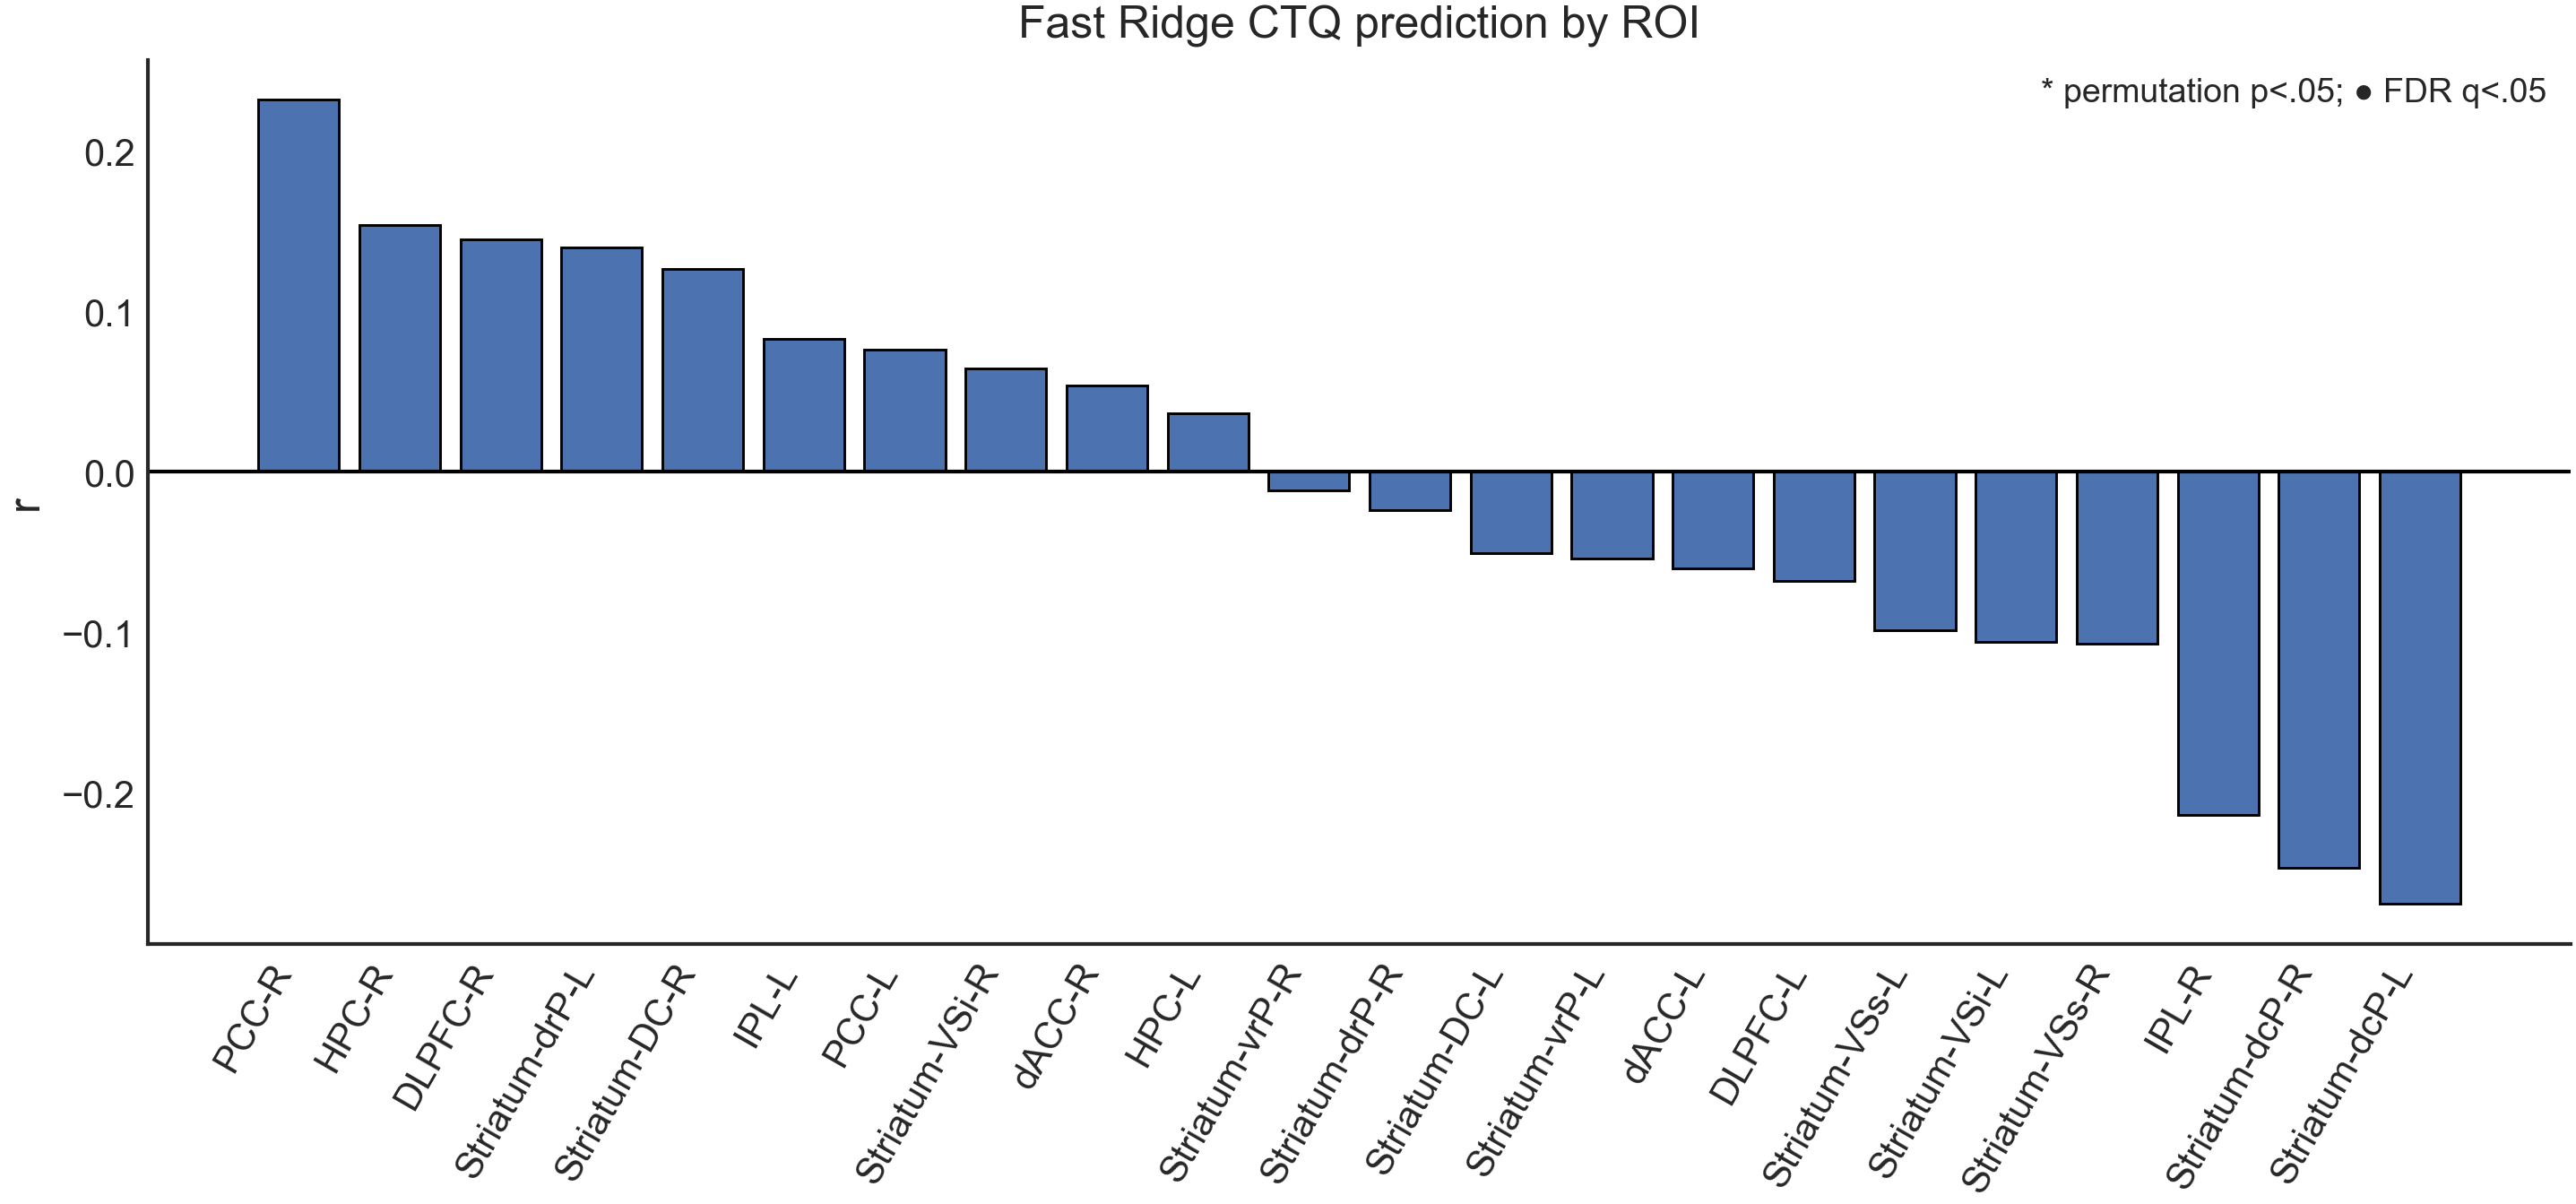

In [9]:
# ============================================================
# CLEAN FAST CTQ RIDGE SCREEN + SINGLE RESULTS PLOT
#
# Assumes your CTQ regression functions are already defined above:
#   - run_ctq_roi_regression_screen(...)
#   - infer_rois(...)
#
# Assumes notebook has:
#   - subject_data
#   - data
# ============================================================

from pathlib import Path
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ----------------------------
# Simple fast settings
# ----------------------------

RESULTS_DIR = Path("../../../analyses/lss_decision/ctq_regression")
RESULT_PREFIX = "ctq_fast_ridge_simple"

FAST_CTQ_SETTINGS = dict(
    # Target / metadata
    target_col="ctq_score",
    subject_col="sub_id",
    covariates=["dx", "sex", "fd_mean", "memory_mean"],

    # Model: Ridge only
    model_keys=("ridge",),
    ridge_alphas=(0.1, 10.0, 1000.0),
    elasticnet_alphas=(0.01,),   # ignored because model_keys=("ridge",)
    l1_ratios=(0.5,),            # ignored because model_keys=("ridge",)
    k_grid=(300,),               # fixed k; SafeSelectKBestRegression clamps if ROI has <300 features

    # CV / permutation speed
    n_splits=3,
    inner_splits=2,
    inner_scoring="neg_mae",
    n_permutations=10,
    permutation_scheme="auto",   # Freedman-Lane when covariates are present
    random_state=1,
    min_n=10,

    # Covariate adjustment
    residualize_target=True,
    residualize_features=True,
    keep_feature_mean=True,

    # ROI feature setup
    fisher=True,
    drop_neutral=False,
    nonfinite_betas="raise",

    # Parallelization
    n_jobs=1,        # keep inner search serial
    perm_n_jobs=1,   # keep permutations serial when ROI parallelism is on
    roi_n_jobs=-1,   # parallelize across ROIs if your function supports this
    blas_threads=1,

    # Resume behavior
    skip_existing=True,
    skip_by="roi",
    only_skip_successful=False,
    overwrite_existing=False,
    show_permutation_progress=False,

    # Ranking / output
    primary_metric="r",
)


# ----------------------------
# Helper: pass only args supported by your current function version
# ----------------------------

def call_with_supported_kwargs(fn, *args, **kwargs):
    """
    Lets this run whether your current run_ctq_roi_regression_screen
    is the older version or the faster parallelized version.
    Unsupported kwargs are silently dropped.
    """
    sig = inspect.signature(fn)
    supported = {
        k: v for k, v in kwargs.items()
        if k in sig.parameters
    }
    dropped = sorted(set(kwargs) - set(supported))
    if dropped:
        print(f"Dropped unsupported arguments for {fn.__name__}: {dropped}")
    return fn(*args, **supported)


# ----------------------------
# Single clean runner
# ----------------------------

def run_clean_fast_ctq_screen(
    subject_data,
    data,
    *,
    rois=None,
    results_dir=RESULTS_DIR,
    result_prefix=RESULT_PREFIX,
    settings=FAST_CTQ_SETTINGS,
):
    results_dir = Path(results_dir)
    results_dir.mkdir(parents=True, exist_ok=True)

    if rois is None:
        rois = infer_rois(subject_data)

    outputs = call_with_supported_kwargs(
        run_ctq_roi_regression_screen,
        subject_data,
        data,
        rois=rois,
        results_dir=results_dir,
        result_prefix=result_prefix,
        **settings,
    )

    return outputs


# ----------------------------
# FDR helper for the plot
# ----------------------------

def bh_fdr(pvals):
    """
    Benjamini-Hochberg FDR correction.
    Returns q-values in the original order.
    """
    p = np.asarray(pvals, dtype=float)
    q = np.full_like(p, np.nan, dtype=float)

    ok = np.isfinite(p)
    if ok.sum() == 0:
        return q

    p_ok = p[ok]
    order = np.argsort(p_ok)
    ranked = p_ok[order]
    m = len(ranked)

    q_ranked = ranked * m / np.arange(1, m + 1)
    q_ranked = np.minimum.accumulate(q_ranked[::-1])[::-1]
    q_ranked = np.clip(q_ranked, 0, 1)

    q_ok = np.empty_like(q_ranked)
    q_ok[order] = q_ranked
    q[ok] = q_ok
    return q


# ----------------------------
# Single results plot
# ----------------------------

def p_to_stars(p):
    try:
        p = float(p)
    except Exception:
        return ""
    if not np.isfinite(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""


def plot_ctq_roi_results_single(
    results_df,
    *,
    metric="r",
    p_col="perm_p_r",
    fdr_col="perm_fdr_r",
    max_rois=30,
    title="Fast Ridge CTQ prediction by ROI",
    save_path=None,
):
    """
    Single summary plot:
      - x-axis: ROI
      - y-axis: cross-validated prediction metric, default Pearson r
      - stars: uncorrected permutation p-value
      - dot: FDR q < .05
    """
    if results_df is None or results_df.empty:
        raise ValueError("results_df is empty.")

    d = results_df.copy()

    if "error" in d.columns:
        d = d[d["error"].fillna("").astype(str) == ""].copy()

    if metric not in d.columns:
        raise KeyError(f"Metric column not found: {metric}")

    d[metric] = pd.to_numeric(d[metric], errors="coerce")
    d = d[np.isfinite(d[metric])].copy()

    if d.empty:
        raise ValueError(f"No successful rows with finite {metric}.")

    if p_col in d.columns:
        d[p_col] = pd.to_numeric(d[p_col], errors="coerce")
        if fdr_col not in d.columns:
            d[fdr_col] = bh_fdr(d[p_col].to_numpy(float))

    lower_is_better = metric in {"mae", "rmse"}
    d = d.sort_values(metric, ascending=lower_is_better)

    if max_rois is not None:
        d = d.head(int(max_rois)).copy()

    x = np.arange(len(d))
    y = d[metric].to_numpy(float)

    fig_width = max(8, 0.45 * len(d))
    fig, ax = plt.subplots(figsize=(fig_width, 4.8))

    ax.bar(x, y, edgecolor="black", linewidth=0.7)
    ax.axhline(0, color="black", linewidth=1)

    ax.set_xticks(x)
    ax.set_xticklabels(d["roi"].astype(str), rotation=60, ha="right")
    ax.set_ylabel(metric)
    ax.set_xlabel("")
    ax.set_title(title)

    ymin, ymax = ax.get_ylim()
    yrange = ymax - ymin if ymax > ymin else 1.0
    pad = 0.04 * yrange

    for i, row in enumerate(d.itertuples(index=False)):
        bar_y = y[i]

        if p_col in d.columns:
            p = getattr(row, p_col, np.nan)
            stars = p_to_stars(p)
            if stars:
                ax.text(
                    i,
                    bar_y + pad if bar_y >= 0 else bar_y - pad,
                    stars,
                    ha="center",
                    va="bottom" if bar_y >= 0 else "top",
                    fontsize=12,
                )

        if fdr_col in d.columns:
            q = getattr(row, fdr_col, np.nan)
            if np.isfinite(q) and q < 0.05:
                ax.text(
                    i,
                    bar_y + 2.3 * pad if bar_y >= 0 else bar_y - 2.3 * pad,
                    "●",
                    ha="center",
                    va="bottom" if bar_y >= 0 else "top",
                    fontsize=9,
                )

    if p_col in d.columns:
        ax.text(
            0.99,
            0.98,
            "* permutation p<.05; ● FDR q<.05",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=9,
        )

    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, ax, d


# ----------------------------
# Run it
# ----------------------------

ctq_outputs = run_clean_fast_ctq_screen(
    subject_data,
    data,
    rois=None,
    results_dir=RESULTS_DIR,
    result_prefix=RESULT_PREFIX,
)

ctq_results = ctq_outputs["screen_df"]
ctq_predictions = ctq_outputs.get("prediction_df", pd.DataFrame())
ctq_permutations = ctq_outputs.get("permutation_df", pd.DataFrame())

single_plot_path = RESULTS_DIR / f"{RESULT_PREFIX}_single_plot.png"

fig, ax, ctq_plot_df = plot_ctq_roi_results_single(
    ctq_results,
    metric="r",
    p_col="perm_p_r",
    fdr_col="perm_fdr_r",
    max_rois=30,
    title="Fast Ridge CTQ prediction by ROI",
    save_path=single_plot_path,
)

print("\nResults written to:")
if "paths" in ctq_outputs:
    for _, row in ctq_outputs["paths"].iterrows():
        print(f"  {row['name']}: {row['path']}")
else:
    print(f"  screen: {RESULTS_DIR / f'{RESULT_PREFIX}_screen.csv'}")
    print(f"  predictions: {RESULTS_DIR / f'{RESULT_PREFIX}_predictions.csv'}")
    print(f"  permutations: {RESULTS_DIR / f'{RESULT_PREFIX}_permutations.csv'}")

print(f"  single plot: {single_plot_path}")

summary_cols = [
    "roi", "model", "n", "n_trials", "n_features",
    "r", "perm_p_r", "perm_fdr_r",
    "spearman", "r2", "mae", "rmse",
    "best_alpha_mode", "best_k_mode", "inner_score_mean",
    "error",
]
summary_cols = [c for c in summary_cols if c in ctq_results.columns]

try:
    display(ctq_results[summary_cols].head(20))
except NameError:
    print(ctq_results[summary_cols].head(20).to_string(index=False))

<h1 align=center>V2</h1>

## Whole trial-similarity geometry analysis

As simple as possible

Show better than chance and better than covariates before interpreting

## Neural feature discovery

In [ ]:
from scipy.spatial.distance import pdist
from statsmodels.stats.multitest import fdrcorrection
from tqdm.auto import tqdm

def make_y_dx(meta, col="dx"):
    """Binary 0/1 outcome."""
    y = pd.to_numeric(meta[col], errors="coerce").to_numpy(float)
    return y, np.isin(y, [0, 1])

def make_y_continuous(col, zscore=True):
    """Factory for continuous outcomes (e.g. CTQ)."""
    def _maker(meta):
        y = pd.to_numeric(meta[col], errors="coerce").to_numpy(float)
        valid = np.isfinite(y)
        if zscore and valid.sum() >= 2:
            yv = y[valid]
            y = (y - yv.mean()) / (yv.std(ddof=1) + 1e-12)
        return y, valid
    return _maker

def _roi_features(ROI, incl_subs, subject_data):
    sims, ids, n_trials = [], [], None
    for sid in incl_subs:
        try:
            b = subject_data[sid]["roi_betas"][ROI]
        except KeyError:
            print(f"Missing {ROI} for subject {sid}", flush=True)
            continue
        b = clean_roi_betas(drop_neutral_trials(b))
        sims.append(1 - pdist(b, metric="correlation"))
        ids.append(sid)
        n_trials = b.shape[0]
    return np.vstack(sims), ids, n_trials

def _zscore_cols(C):
    sd = np.nanstd(C, axis=0, ddof=1)
    keep = np.isfinite(sd) & (sd > 1e-8)
    C = C[:, keep]
    if C.shape[1]:
        C = (C - C.mean(0, keepdims=True)) / (C.std(0, ddof=1, keepdims=True) + 1e-12)
    return C, keep

def _perm_fit(X, y, C, n_perm, rng):
    """OLS of each pair on [1, y, C]; permute y for RMS null."""
    design = np.column_stack([np.ones(len(y)), y, C])
    d_pair = np.linalg.lstsq(design, X, rcond=None)[0][1]
    rms    = float(np.sqrt(np.mean(d_pair ** 2)))
    null   = np.empty(n_perm)
    for p in range(n_perm):
        dp = np.column_stack([np.ones(len(y)), rng.permutation(y), C])
        null[p] = np.sqrt(np.mean(np.linalg.lstsq(dp, X, rcond=None)[0][1] ** 2))
    return d_pair, rms, null

def roi_screen(rois, y_maker, covariates, *, incl_subs, subject_data, meta_df,
               target_name="y", n_perm=1000, random_state=1):
    rng = np.random.default_rng(random_state)
    rows = []
    out = {"dpair": {}, "X": {}, "meta": {}, "pair_index": {}, "nulls": {}}

    for ROI in tqdm(rois, desc=f"ROI screen ({target_name})"):
        X, ids, n_trials = _roi_features(ROI, incl_subs, subject_data)
        meta = pd.DataFrame({"sub_id": ids}).merge(meta_df, on="sub_id", how="left")

        y, valid_y = y_maker(meta)
        cov_arr    = meta[covariates].apply(pd.to_numeric, errors="coerce").to_numpy(float)
        valid      = valid_y & np.isfinite(cov_arr).all(axis=1) & np.isfinite(X).all(axis=1)

        meta = meta.loc[valid].reset_index(drop=True)
        X, y = X[valid], y[valid]
        C, keep   = _zscore_cols(cov_arr[valid])
        covs_used = [c for c, k in zip(covariates, keep) if k]

        d_pair, rms, null = _perm_fit(X, y, C, n_perm, rng)
        p_perm = float((1 + (null >= rms).sum()) / (1 + n_perm))
        z_perm = float((rms - null.mean()) / (null.std(ddof=1) + 1e-12))

        rows.append({
            "roi": ROI, "target": target_name,
            "n": int(X.shape[0]), "n_trials": int(n_trials),
            "n_pairs": int(X.shape[1]),
            "rms_diff": rms, "p_perm": p_perm, "z_perm": z_perm,
            "null_mean": float(null.mean()), "null_sd": float(null.std(ddof=1)),
            "covariates_used": ", ".join(covs_used),
        })

        iu = np.triu_indices(n_trials, k=1)
        out["dpair"][ROI]      = d_pair
        out["X"][ROI]          = X
        out["meta"][ROI]       = meta.assign(**{target_name: y})
        out["pair_index"][ROI] = pd.DataFrame(
            {"pair_idx": np.arange(X.shape[1]), "trial_i": iu[0], "trial_j": iu[1]})
        out["nulls"][ROI]      = null

    df = pd.DataFrame(rows)
    _, df["p_fdr"] = fdrcorrection(df["p_perm"])
    out["screen_df"] = df.sort_values("p_perm").reset_index(drop=True)
    return out

# ============================================================
# Run
# ============================================================

ROIS = list(subject_data[18001]["roi_betas"].keys())

dx = roi_screen(
    ROIS, make_y_dx,
    covariates=["sex", "fd_mean", "memory_mean"],
    incl_subs=incl_subs, subject_data=subject_data, meta_df=data,
    target_name="dx",
)

ctq = roi_screen(
    ROIS, make_y_continuous("ctq_score"),
    covariates=["sex", "fd_mean", "memory_mean", "dx"],
    incl_subs=incl_subs, subject_data=subject_data, meta_df=data,
    target_name="ctq",
)

# Preserve the variable names the pipeline expects
roi_screen_df  = dx["screen_df"]
roi_dpair      = dx["dpair"]
roi_X          = dx["X"]
roi_meta       = dx["meta"]
roi_pair_index = dx["pair_index"]
roi_nulls      = dx["nulls"]

### Try to rule out simple confounds, boring differences

In [ ]:
# # ============================================================
# # Config
# # ============================================================

# FDR_THRESH      = 0.05
# TOP_K_FALLBACK  = 6
# ROBUST_PCT      = 99
# BIN_WIDTH       = 5
# ROLLING_WIN     = 5

# sig_rois = roi_screen_df.loc[roi_screen_df["p_fdr"] < FDR_THRESH, "roi"].tolist()
# if not sig_rois:
#     sig_rois = roi_screen_df.sort_values("p_perm").head(TOP_K_FALLBACK)["roi"].tolist()
#     print(f"No ROIs at q<{FDR_THRESH}; showing top {len(sig_rois)} by p_perm.")
# n_rois = len(sig_rois)

# # ============================================================
# # Build pair-level frame
# # ============================================================

# def _build_pair_frame(ROI):
#     df = roi_pair_index[ROI].copy()
#     d  = np.asarray(roi_dpair[ROI], float)
#     ti = df["trial_i"].to_numpy(int)
#     tj = df["trial_j"].to_numpy(int)
#     df = df.assign(
#         roi           = ROI,
#         CD_minus_HC   = d,
#         trial_lag     = np.abs(ti - tj),
#         pair_midpoint = (ti + tj) / 2.0,
#     )
#     return df[np.isfinite(df["CD_minus_HC"])].copy()

# pair_df = pd.concat([_build_pair_frame(r) for r in sig_rois], ignore_index=True)

# # ============================================================
# # Unified temporal model
# # ============================================================

# def _z(x):
#     x  = np.asarray(x, float)
#     sd = np.nanstd(x, ddof=1)
#     return (x - np.nanmean(x)) / (sd + 1e-12)

# def _design(lag, mid, use_lag=True, use_mid=True):
#     cols, lz, mz = [], _z(lag), _z(mid)
#     if use_lag:               cols += [lz, lz**2]
#     if use_mid:               cols += [mz, mz**2]
#     if use_lag and use_mid:   cols += [lz * mz]
#     return np.column_stack(cols) if cols else np.zeros((len(lag), 0))

# def fit_temporal(y, lag, mid, use_lag=True, use_mid=True):
#     """Returns (yhat, descriptive variance explained). y is mean-centered."""
#     y  = np.asarray(y, float)
#     yc = y - np.mean(y)
#     X  = _design(lag, mid, use_lag, use_mid)
#     if X.shape[1] == 0:
#         return np.zeros_like(yc), 0.0
#     beta, *_ = np.linalg.lstsq(X, yc, rcond=None)
#     yhat = X @ beta
#     ve = 1 - np.sum((yc - yhat) ** 2) / (np.sum(yc ** 2) + 1e-12)
#     return yhat, ve

# def temporal_residualize(g):
#     """CD-HC with temporal trend removed; ROI mean preserved."""
#     y = g["CD_minus_HC"].to_numpy(float)
#     yhat, _ = fit_temporal(y, g["trial_lag"], g["pair_midpoint"])
#     return y - yhat

# pair_df["CD_minus_HC_time_adj"] = np.nan
# for ROI in sig_rois:
#     m = pair_df["roi"] == ROI
#     pair_df.loc[m, "CD_minus_HC_time_adj"] = temporal_residualize(pair_df.loc[m])

# # ============================================================
# # Trial-cluster jackknife for the mean
# # ============================================================

# def trial_jackknife_se(g, col="CD_minus_HC"):
#     y  = g[col].to_numpy(float)
#     ti = g["trial_i"].to_numpy(int)
#     tj = g["trial_j"].to_numpy(int)
#     trials = np.unique(np.concatenate([ti, tj]))
#     n = len(trials)
#     if n < 3:
#         return np.nan
#     means = np.empty(n)
#     for k, t in enumerate(trials):
#         keep = (ti != t) & (tj != t)
#         means[k] = np.mean(y[keep]) if keep.any() else np.nan
#     means = means[np.isfinite(means)]
#     return np.sqrt((n - 1) / n * np.sum((means - means.mean()) ** 2))

# # ============================================================
# # Summary
# # ============================================================

# rows = []
# for ROI in sig_rois:
#     g  = pair_df[pair_df["roi"] == ROI]
#     d  = g["CD_minus_HC"].to_numpy(float)
#     da = g["CD_minus_HC_time_adj"].to_numpy(float)
#     sc = roi_screen_df.loc[roi_screen_df["roi"] == ROI].iloc[0]

#     _, ve_lag  = fit_temporal(d, g["trial_lag"], g["pair_midpoint"], use_lag=True,  use_mid=False)
#     _, ve_mid  = fit_temporal(d, g["trial_lag"], g["pair_midpoint"], use_lag=False, use_mid=True)
#     _, ve_full = fit_temporal(d, g["trial_lag"], g["pair_midpoint"], use_lag=True,  use_mid=True)

#     rows.append({
#         "roi": ROI,
#         "p_perm": sc["p_perm"], "p_fdr": sc["p_fdr"],
#         "n_pairs": len(d),
#         "mean_raw":      np.mean(d),
#         "mean_time_adj": np.mean(da),
#         "median_raw":    np.median(d),
#         "jk_se_raw":     trial_jackknife_se(g, "CD_minus_HC"),
#         "jk_se_adj":     trial_jackknife_se(g, "CD_minus_HC_time_adj"),
#         "frac_below_0":  np.mean(d < 0),
#         "ve_lag":        ve_lag,
#         "ve_midpoint":   ve_mid,
#         "ve_full":       ve_full,
#         "incr_ve_lag":   ve_full - ve_mid,   # lag | midpoint
#         "incr_ve_mid":   ve_full - ve_lag,   # midpoint | lag
#     })

# summary_df = pd.DataFrame(rows).sort_values("mean_raw")
# roi_order  = summary_df["roi"].tolist()
# pair_df["roi"] = pd.Categorical(pair_df["roi"], categories=roi_order, ordered=True)
# S = summary_df.set_index("roi")

# print_df(summary_df)

# # ============================================================
# # Matrix builder
# # ============================================================

# def make_roi_diff_matrix(ROI, col="CD_minus_HC"):
#     g = pair_df[pair_df["roi"] == ROI]
#     n = int(max(g["trial_i"].max(), g["trial_j"].max()) + 1)
#     D = np.full((n, n), np.nan)
#     i = g["trial_i"].to_numpy(int)
#     j = g["trial_j"].to_numpy(int)
#     v = g[col].to_numpy(float)
#     D[i, j] = v
#     D[j, i] = v
#     np.fill_diagonal(D, np.nan)
#     return D

# # ============================================================
# # Heatmap grid (used for both raw and time-adjusted)
# # ============================================================

# def plot_heatmap_grid(col, suptitle, cbar_label, scale_to="self"):
#     """scale_to='self' uses each matrix's own percentile; 'raw' uses the raw
#     matrix's percentile so adjusted/raw heatmaps are visually comparable."""
#     n_cols = min(4, n_rois)
#     n_rows = int(np.ceil(n_rois / n_cols))
#     fig, axes = plt.subplots(n_rows, n_cols,
#                              figsize=(4.8 * n_cols, 4.4 * n_rows),
#                              squeeze=False)
#     axes = axes.ravel()

#     for ax, ROI in zip(axes, roi_order):
#         D = make_roi_diff_matrix(ROI, col=col)
#         ref = make_roi_diff_matrix(ROI, "CD_minus_HC") if scale_to == "raw" else D
#         vmax = np.nanpercentile(np.abs(ref), ROBUST_PCT)
#         vmax = vmax if (np.isfinite(vmax) and vmax > 0) else 1e-6

#         sns.heatmap(D, ax=ax, cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax,
#                     mask=~np.isfinite(D), square=True,
#                     xticklabels=6, yticklabels=6,
#                     cbar_kws={"shrink": 0.75, "label": cbar_label,
#                               "ticks": [-vmax, 0, vmax]})
#         s = S.loc[ROI]
#         ax.set_title(
#             f"{ROI}\n"
#             f"mean raw={s['mean_raw']:.3f}  adj={s['mean_time_adj']:.3f}\n"
#             f"VE(lag,mid)={s['ve_full']:.2f}  "
#             f"Δlag|mid={s['incr_ve_lag']:.2f}",
#             fontsize=9,
#         )
#         ax.set_xlabel("Trial"); ax.set_ylabel("Trial")

#     for ax in axes[n_rois:]:
#         ax.axis("off")
#     fig.suptitle(suptitle, y=1.01, fontsize=14)
#     plt.tight_layout(); plt.show()

# plot_heatmap_grid(
#     "CD_minus_HC",
#     "Trial-pair neural similarity differences by ROI",
#     "CD − HC",
#     scale_to="self",
# )

# plot_heatmap_grid(
#     "CD_minus_HC_time_adj",
#     "Time-adjusted differences (lag and pair-midpoint residualized; same scale as raw)",
#     "CD − HC, residual",
#     scale_to="raw",
# )

# # ============================================================
# # Distribution with trial-cluster jackknife CIs
# # ============================================================

# fig, ax = plt.subplots(figsize=(max(6, 1.7 * n_rois), 4.2))
# sns.violinplot(data=pair_df, x="roi", y="CD_minus_HC",
#                order=roi_order, inner="quartile", cut=0,
#                color="lightgray", linewidth=0.8, ax=ax)
# sns.stripplot(data=pair_df, x="roi", y="CD_minus_HC",
#               order=roi_order, color="black", alpha=0.04, size=1,
#               jitter=0.25, ax=ax)

# xs = np.arange(len(roi_order))
# ax.errorbar(xs, S["mean_raw"].to_numpy(),
#             yerr=1.96 * S["jk_se_raw"].to_numpy(),
#             fmt="D", color="red", markersize=5, capsize=3, zorder=10,
#             label="Mean ± 1.96·jackknife SE over trials")
# ax.errorbar(xs + 0.18, S["mean_time_adj"].to_numpy(),
#             yerr=1.96 * S["jk_se_adj"].to_numpy(),
#             fmt="o", color="C0", markersize=4, capsize=3, zorder=10,
#             label="Time-adjusted mean ± 1.96·jackknife SE")
# ax.axhline(0, color="black", lw=1)
# ax.set_ylabel("CD − HC neural similarity")
# ax.set_xlabel("")
# ax.set_title("Pair-difference distribution; means with trial-cluster jackknife CIs")
# ax.legend(loc="lower right", fontsize=8)
# plt.xticks(rotation=45, ha="right")
# plt.tight_layout(); plt.show()

# # ============================================================
# # Trial trace (mean diff for each trial vs all others)
# # ============================================================

# trial_rows = []
# for ROI in roi_order:
#     D = make_roi_diff_matrix(ROI, "CD_minus_HC")
#     trial_rows.append(pd.DataFrame({
#         "roi": ROI,
#         "trial": np.arange(D.shape[0]),
#         "trial_mean": np.nanmean(D, axis=1),
#         "trial_n":    np.sum(np.isfinite(D), axis=1),
#     }))
# trial_df = pd.concat(trial_rows, ignore_index=True)
# trial_df["roi"] = pd.Categorical(trial_df["roi"], categories=roi_order, ordered=True)
# trial_df["trial_mean_smooth"] = (
#     trial_df.groupby("roi", observed=True)["trial_mean"]
#             .transform(lambda x: x.rolling(ROLLING_WIN, center=True, min_periods=1).mean())
# )

# g = sns.FacetGrid(trial_df, col="roi", col_wrap=4, height=2.4, aspect=1.4, sharey=True)
# def _trial_trace(data, **kw):
#     ax = plt.gca()
#     data = data.sort_values("trial")
#     ax.plot(data["trial"], data["trial_mean"],        color="0.65", lw=0.8, alpha=0.7)
#     ax.plot(data["trial"], data["trial_mean_smooth"], color="black", lw=1.8)
#     ax.axhline(0, color="red", lw=1, alpha=0.8)
# g.map_dataframe(_trial_trace)
# for ax in g.axes.flat:
#     ax.set_xlabel("Trial"); ax.set_ylabel("Mean CD − HC")
# g.fig.suptitle("Which trials drive the ROI difference?", y=1.04, fontsize=14)
# plt.tight_layout(); plt.show()

# # ============================================================
# # Lag and midpoint marginals (binned, with CIs)
# # ============================================================

# def _binned_marginal(df, x_col):
#     df = df.copy()
#     df["bin"] = (df[x_col] // BIN_WIDTH) * BIN_WIDTH
#     out = (df.groupby(["roi", "bin"], observed=True)["CD_minus_HC"]
#              .agg(mean="mean", sd="std", count="count")
#              .reset_index())
#     out["sem"]    = out["sd"]   / np.sqrt(out["count"])
#     out["ci95"]   = 1.96 * out["sem"]
#     out["bin_mid"] = out["bin"] + BIN_WIDTH / 2
#     return out

# def _plot_marginal(summary, x_col, suptitle, xlabel):
#     g = sns.FacetGrid(summary, col="roi", col_wrap=4, height=2.4, aspect=1.4, sharey=True)
#     def draw(data, **kw):
#         ax = plt.gca()
#         data = data.sort_values(x_col)
#         x  = data[x_col].to_numpy(float)
#         y  = data["mean"].to_numpy(float)
#         ci = data["ci95"].to_numpy(float)
#         ax.plot(x, y, color="black", lw=1.8)
#         ax.fill_between(x, y - ci, y + ci, color="black", alpha=0.15, linewidth=0)
#         ax.axhline(0, color="red", lw=1, alpha=0.8)
#     g.map_dataframe(draw)
#     for ax in g.axes.flat:
#         ax.set_xlabel(xlabel); ax.set_ylabel("Mean CD − HC")
#     g.fig.suptitle(suptitle + "  (CIs do not account for pair non-independence)",
#                    y=1.04, fontsize=12)
#     plt.tight_layout(); plt.show()

# lag_summary = _binned_marginal(pair_df[["roi","trial_lag","CD_minus_HC"]]
#                                .rename(columns={"trial_lag":"x"}), "x")
# lag_summary = lag_summary.rename(columns={"bin_mid":"lag_mid"})
# _plot_marginal(lag_summary.rename(columns={"lag_mid":"x"}), "x",
#                "ROI difference vs trial lag", "Trial lag")

# mid_summary = _binned_marginal(pair_df[["roi","pair_midpoint","CD_minus_HC"]]
#                                .rename(columns={"pair_midpoint":"x"}), "x")
# _plot_marginal(mid_summary.rename(columns={"bin_mid":"x"}), "x",
#                "ROI difference vs pair midpoint (task position)", "Pair midpoint")

# # ============================================================
# # Joint midpoint × lag heatmap (disambiguates the two)
# # ============================================================

# def _joint_mid_lag(ROI):
#     g = pair_df[pair_df["roi"] == ROI].copy()
#     g["lag_bin"] = (g["trial_lag"]     // BIN_WIDTH) * BIN_WIDTH
#     g["mid_bin"] = (g["pair_midpoint"] // BIN_WIDTH) * BIN_WIDTH
#     # rows = lag (y), cols = midpoint (x)
#     return (g.groupby(["lag_bin","mid_bin"], observed=True)["CD_minus_HC"]
#               .mean().unstack("mid_bin"))

# n_cols = min(4, n_rois); n_rows = int(np.ceil(n_rois / n_cols))
# fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.6*n_cols, 3.8*n_rows), squeeze=False)
# for ax, ROI in zip(axes.ravel(), roi_order):
#     M = _joint_mid_lag(ROI)
#     if M.empty:
#         ax.axis("off"); continue
#     vmax = np.nanpercentile(np.abs(M.values), ROBUST_PCT)
#     vmax = vmax if (np.isfinite(vmax) and vmax > 0) else 1e-6
#     sns.heatmap(M, ax=ax, cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax,
#                 cbar_kws={"label":"CD − HC", "shrink":0.75})
#     # lag increases upward on y; midpoint increases rightward on x (default)
#     ax.set_title(ROI, fontsize=10)
#     ax.set_xlabel("Pair midpoint (task position)")
#     ax.set_ylabel("Trial lag")
# for ax in axes.ravel()[n_rois:]:
#     ax.axis("off")
# fig.suptitle("Joint midpoint × lag structure of CD − HC", y=1.02, fontsize=14)
# plt.tight_layout(); plt.show()

## Task-relevant feature discovery

In [ ]:
task_df = decision_trials[["character_role_num", "character_decision_num", "dimension"]].copy()
task_df["dimension"] = task_df["dimension"].astype(str)

def add_task_features(pdf, tdf):
    chari = tdf["character_role_num"].to_numpy()
    chard = tdf["character_decision_num"].to_numpy()
    dim   = tdf["dimension"].to_numpy()
    ti, tj = pdf["trial_i"].to_numpy(int), pdf["trial_j"].to_numpy(int)

    out = pdf.copy()
    out["same_character"] = chari[ti] == chari[tj]
    out["same_dimension"] = dim[ti]   == dim[tj]
    out["dim_pair"] = np.where(
        dim[ti] == dim[tj],
        np.where(dim[ti] == "affil", "AA", "PP"),
        "AP",
    )
    out["char_decision_lag"] = np.where(
        out["same_character"],
        np.abs(chard[ti].astype(float) - chard[tj].astype(float)),
        np.nan,
    )
    return out

# ============================================================
# Contrast definitions (mask of pairs per partition)
# ============================================================

PARTITION_MASKS = {
    "mean_overall": lambda p: np.ones(len(p), bool),
    "same_char":    lambda p: p["same_character"].to_numpy(bool),
    "diff_char":    lambda p: (~p["same_character"]).to_numpy(bool),
    "same_dim":     lambda p: p["same_dimension"].to_numpy(bool),
    "diff_dim":     lambda p: (~p["same_dimension"]).to_numpy(bool),
    "AA":           lambda p: (p["dim_pair"] == "AA").to_numpy(bool),
    "PP":           lambda p: (p["dim_pair"] == "PP").to_numpy(bool),
    "AP":           lambda p: (p["dim_pair"] == "AP").to_numpy(bool),
}

DERIVED = {
    "char_effect":       ("same_char", "diff_char"),
    "dim_effect":        ("same_dim",  "diff_dim"),
    "affil_minus_power": ("AA", "PP"),
}

# ============================================================
# Subject-level contrasts: works for any screen_out from roi_screen()
# ============================================================

def subject_contrasts(screen_out, task_df, target_name, covariates, rois=None):
    rois = rois or list(screen_out["X"].keys())
    rows = []

    for ROI in rois:
        X    = screen_out["X"][ROI]
        meta = screen_out["meta"][ROI].reset_index(drop=True)
        pix  = add_task_features(screen_out["pair_index"][ROI], task_df)

        masks   = {n: fn(pix) for n, fn in PARTITION_MASKS.items()}
        cov_arr = meta[covariates].apply(pd.to_numeric, errors="coerce").to_numpy(float)
        cov_z   = (cov_arr - np.nanmean(cov_arr, 0)) / (np.nanstd(cov_arr, 0, ddof=1) + 1e-12)

        for s in range(X.shape[0]):
            sims = X[s]
            row = {"sub_id": meta.loc[s, "sub_id"],
                   target_name: meta.loc[s, target_name],
                   "roi": ROI}
            row.update({c: cov_z[s, k] for k, c in enumerate(covariates)})
            row.update({n: (float(np.nanmean(sims[m])) if m.any() else np.nan)
                        for n, m in masks.items()})
            rows.append(row)

    df = pd.DataFrame(rows)
    for name, (a, b) in DERIVED.items():
        df[name] = df[a] - df[b]
    return df

# ============================================================
# Regression of a contrast on a predictor + covariates
# ============================================================

def regress_contrast(df, y_col, predictor, covariates):
    sub = df.dropna(subset=[y_col, predictor] + list(covariates)).copy()
    y = sub[y_col].to_numpy(float)
    X = np.column_stack([np.ones(len(sub)), sub[predictor].to_numpy(float),
                         sub[list(covariates)].to_numpy(float)])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    dof   = max(len(sub) - X.shape[1], 1)
    se    = np.sqrt(np.diag((resid @ resid) / dof * np.linalg.pinv(X.T @ X)))
    from scipy.stats import t as student_t
    t_  = beta[1] / (se[1] + 1e-12)
    return {"slope": float(beta[1]), "se": float(se[1]),
            "ci_lo": float(beta[1] - 1.96 * se[1]),
            "ci_hi": float(beta[1] + 1.96 * se[1]),
            "p":    float(2 * (1 - student_t.cdf(abs(t_), df=dof))),
            "n":    int(len(sub))}

def test_contrasts(subj_df, predictor, contrasts, covariates, rois):
    rows = []
    for ROI in rois:
        sub = subj_df[subj_df["roi"] == ROI]
        for c in contrasts:
            rows.append({"roi": ROI, "contrast": c,
                         **regress_contrast(sub, c, predictor, covariates)})
    df = pd.DataFrame(rows)
    df["p_fdr"] = np.nan
    for c in contrasts:
        m = df["contrast"] == c
        _, df.loc[m, "p_fdr"] = fdrcorrection(df.loc[m, "p"].to_numpy())
    return df.sort_values(["contrast", "p"]).reset_index(drop=True)

# ============================================================
# Visualization: slope forest plot (works for binary or continuous)
# ============================================================

def plot_slopes(test_df, contrasts, rois, *, predictor_label, suptitle=None,
                figsize_per_panel=(0.55, 3.2)):
    n_c = len(contrasts)
    w   = max(6, figsize_per_panel[0] * len(rois))
    fig, axes = plt.subplots(n_c, 1, figsize=(w, figsize_per_panel[1] * n_c),
                             squeeze=False, sharex=True)
    xs = np.arange(len(rois))

    for ax, c in zip(axes.ravel(), contrasts):
        sub  = test_df[test_df["contrast"] == c].set_index("roi").reindex(rois)
        sig  = sub["p_fdr"] < 0.05
        ax.errorbar(xs, sub["slope"], yerr=1.96 * sub["se"],
                    fmt="o", capsize=3, color="0.3", ecolor="0.6", ms=5)
        if sig.any():
            ax.errorbar(xs[sig.to_numpy()], sub.loc[sig, "slope"],
                        yerr=1.96 * sub.loc[sig, "se"],
                        fmt="o", capsize=3, color="C3", ecolor="C3", ms=6, zorder=10)
        ax.axhline(0, color="black", lw=1)
        ax.set_title(c); ax.set_xticks(xs); ax.set_xticklabels([])
        ax.set_ylabel(f"slope per {predictor_label}")
        ymax = ax.get_ylim()[1]
        for xi, ROI in enumerate(rois):
            q = sub.loc[ROI, "p_fdr"]
            ax.text(xi, ymax, f"q={q:.2g}", ha="center", va="top", fontsize=7,
                    color="C3" if q < 0.05 else "0.5")

    axes.ravel()[-1].set_xticklabels(rois, rotation=45, ha="right")
    if suptitle: fig.suptitle(suptitle, y=1.01)
    plt.tight_layout(); plt.show()

# ============================================================
# Optional: split-violin distribution view (binary predictors only)
# ============================================================

def plot_split_violins(subj_df, contrasts, rois, predictor, level_labels, test_df=None,
                       palette=None):
    palette = palette or {level_labels[0]: "0.7", level_labels[1]: "C3"}
    n_c = len(contrasts)
    fig, axes = plt.subplots(n_c, 1, figsize=(max(6, 1.6 * len(rois)), 3.2 * n_c),
                             squeeze=False, sharex=True)
    for ax, c in zip(axes.ravel(), contrasts):
        sub = subj_df[["roi", predictor, c]].copy()
        sub["group"] = sub[predictor].map(dict(enumerate(level_labels)))
        sns.violinplot(data=sub, x="roi", y=c, hue="group", order=rois,
                       split=True, inner="quartile", cut=0, ax=ax,
                       palette=palette, linewidth=0.7)
        sns.stripplot(data=sub, x="roi", y=c, hue="group", order=rois,
                      dodge=True, size=2, alpha=0.5, ax=ax, palette=palette, legend=False)
        ax.axhline(0, color="black", lw=1); ax.set_title(c); ax.set_xlabel("")
        if test_df is not None:
            ymax = ax.get_ylim()[1]
            for xi, ROI in enumerate(rois):
                row = test_df[(test_df["roi"] == ROI) & (test_df["contrast"] == c)].iloc[0]
                ax.text(xi, ymax, f"q={row['p_fdr']:.2g}", ha="center", va="top",
                        fontsize=7, color="C3" if row["p_fdr"] < 0.05 else "0.5")
    plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

# ============================================================
# Pair-level partition table + within-character lag plot (parameterized)
# ============================================================

def build_pair_df(screen_out, rois, effect_name="effect"):
    """Pair-level frame for sig ROIs with task features and the per-pair coefficient."""
    frames = []
    for ROI in rois:
        d = np.asarray(screen_out["dpair"][ROI], float)
        pix = screen_out["pair_index"][ROI].copy()
        pix = pix.assign(
            roi=ROI,
            **{effect_name: d},
            trial_lag=np.abs(pix["trial_i"] - pix["trial_j"]),
            pair_midpoint=(pix["trial_i"] + pix["trial_j"]) / 2.0,
        )
        frames.append(add_task_features(pix[np.isfinite(d)], task_df))
    return pd.concat(frames, ignore_index=True)

def plot_within_character_lag(pair_df, effect_name, suptitle):
    wc = pair_df[pair_df["same_character"]].copy()
    wc["chard_lag_bin"] = (wc["char_decision_lag"] // 2) * 2
    summ = (wc.groupby(["roi", "chard_lag_bin"], observed=True)[effect_name]
              .agg(mean="mean", count="count").reset_index())
    g = sns.FacetGrid(summ, col="roi", col_wrap=4, height=2.4, aspect=1.4, sharey=True)
    def _draw(data, **kw):
        ax = plt.gca()
        d = data.sort_values("chard_lag_bin")
        ax.plot(d["chard_lag_bin"], d["mean"], color="black", lw=1.5, marker="o", ms=3)
        ax.axhline(0, color="red", lw=1, alpha=0.7)
    g.map_dataframe(_draw)
    for ax in g.axes.flat:
        ax.set_xlabel("Within-character decision lag")
        ax.set_ylabel(f"Mean {effect_name}")
    g.fig.suptitle(suptitle, y=1.04, fontsize=13)
    plt.tight_layout(); plt.show()

# ============================================================
# Run on both screens
# ============================================================

CONTRASTS = ["mean_overall", "char_effect", "dim_effect", "affil_minus_power",
             "same_char", "diff_char", "same_dim", "diff_dim"]
PLOT_CONTRASTS = ["char_effect", "dim_effect", "affil_minus_power"]

dx_covars  = ["sex", "fd_mean", "memory_mean"]
ctq_covars = ["sex", "fd_mean", "memory_mean", "dx"]

# ------------------------ DX (binary)
dx_rois     = list(dx["X"].keys())
dx_subj     = subject_contrasts(dx, task_df, "dx", dx_covars, rois=dx_rois)
dx_test     = test_contrasts(dx_subj, "dx", CONTRASTS, dx_covars, dx_rois)
dx_pair_df  = build_pair_df(dx, dx_rois, effect_name="CD_minus_HC")

plot_slopes(dx_test, PLOT_CONTRASTS, dx_rois,
            predictor_label="CD vs HC",
            suptitle="Task-structure contrasts: CD vs HC")
plot_split_violins(dx_subj, PLOT_CONTRASTS, dx_rois,
                   predictor="dx", level_labels=["HC", "CD"], test_df=dx_test)
plot_within_character_lag(dx_pair_df, "CD_minus_HC",
                          "Within-character pairs: CD − HC by decision-number distance")

# ------------------------ CTQ (continuous)
ctq_rois    = list(ctq["X"].keys())
ctq_subj    = subject_contrasts(ctq, task_df, "ctq", ctq_covars, rois=ctq_rois)
ctq_test    = test_contrasts(ctq_subj, "ctq", CONTRASTS, ctq_covars, ctq_rois)
ctq_pair_df = build_pair_df(ctq, ctq_rois, effect_name="ctq_slope")

plot_slopes(ctq_test, PLOT_CONTRASTS, ctq_rois,
            predictor_label="SD of CTQ",
            suptitle="Task-structure contrasts: scaling with CTQ")
plot_within_character_lag(ctq_pair_df, "ctq_slope",
                          "Within-character pairs: CTQ slope by decision-number distance")

<h1 align=center>V1</h1>

# automated neural feature discovery

In [ ]:
from tqdm.auto import tqdm
from scipy.spatial.distance import pdist
from scipy.stats import spearmanr
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

def sid_key(x):
    """
    Normalize subject ids for matching across dataframes / dictionaries.
    """
    s = str(x).strip()
    if s.startswith("sub-"):
        s = s[4:]
    if s.isdigit():
        return str(int(s))
    return s

def get_subject_dict(subject_data, sub_id):
    """
    Robust lookup for subject_data, because keys may be int/string/sub-XXX.
    """
    candidates = [
        sub_id,
        str(sub_id),
        sid_key(sub_id),
        f"sub-{sid_key(sub_id)}",
    ]

    if sid_key(sub_id).isdigit():
        candidates.append(int(sid_key(sub_id)))
        candidates.append(str(int(sid_key(sub_id))).zfill(2))
        candidates.append(f"sub-{str(int(sid_key(sub_id))).zfill(2)}")

    for c in candidates:
        if c in subject_data:
            return subject_data[c]

    return None

def get_role_col(behavior):
    if behavior is None:
        return None
    if "character_role_num" in behavior.columns:
        return "character_role_num"
    if "char_role_num" in behavior.columns:
        return "char_role_num"
    return None

def drop_neutral_rows(X, behavior):
    """
    Drop neutral-character trials if behavior has character-role labels.
    """
    if behavior is None:
        return X, behavior

    role_col = get_role_col(behavior)
    if role_col is None:
        return X, behavior

    if len(behavior) != X.shape[0]:
        return X, behavior

    keep = behavior[role_col].to_numpy() != 6
    X = X[keep]
    behavior = behavior.loc[keep].reset_index(drop=True)

    return X, behavior

# ------------------------------------------------------------
# Build ROI-wise subject × feature matrices
# ------------------------------------------------------------

def trial_pattern_similarity_feature(
    X,
    *,
    behavior=None,
    drop_neutral=True,
    min_voxels=5,
    eps=1e-8,
):
    """
    Input:
        X: trials × voxels beta matrix for one subject / ROI

    Output:
        feature vector = upper triangle of trial × trial correlation matrix

    This is the simplest data-driven representation of the ROI:
    how this ROI organizes all task trials relative to each other.
    """

    if X is None:
        return None, None

    X = np.asarray(X, float)

    if X.ndim != 2:
        return None, None

    if drop_neutral:
        X, behavior = drop_neutral_rows(X, behavior)

    X = clean_roi_betas(X, min_voxels=min_voxels)
    if X is None:
        return None, None

    # Row-wise z-score: each trial pattern standardized across voxels.
    # Then trial × trial Pearson correlation is just dot product / (V - 1).
    Z = X - np.nanmean(X, axis=1, keepdims=True)
    Z = Z / (np.nanstd(Z, axis=1, ddof=1, keepdims=True) + eps)

    R = (Z @ Z.T) / max(Z.shape[1] - 1, 1)

    iu = np.triu_indices(R.shape[0], k=1)
    feat = R[iu]

    if not np.isfinite(feat).all():
        return None, None

    info = {
        "n_trials": X.shape[0],
        "n_voxels": X.shape[1],
        "n_features": feat.size,
    }

    return feat, info

def get_all_rois(subject_data):
    rois = set()
    for sd in subject_data.values():
        if isinstance(sd, dict) and isinstance(sd.get("roi_betas"), dict):
            rois.update(sd["roi_betas"].keys())
    return sorted(rois)

def make_roi_feature_bank(
    subject_data,
    meta,
    *,
    sub_col="sub_id",
    min_subjects=10,
    min_voxels=5,
    drop_neutral=True,
):
    """
    Returns:
        roi_feature_bank[roi] = {
            "X": subjects × trial-pair features,
            "sub_ids": subject ids in same order as X,
            "n_voxels": mean retained voxels per subject,
            "n_trials": number of trials used,
        }
    """

    rois = get_all_rois(subject_data)
    roi_feature_bank = {}

    for roi in tqdm(rois, desc="Building ROI feature bank"):
        feats = []
        sub_ids = []
        n_voxels = []
        n_trials = []

        for _, row in meta.iterrows():
            sub_id = row[sub_col]
            sd = get_subject_dict(subject_data, sub_id)

            if sd is None:
                continue

            roi_betas = sd.get("roi_betas", None)
            if not isinstance(roi_betas, dict):
                continue

            if roi not in roi_betas:
                continue

            behavior = sd.get("behavior", None)

            feat, info = trial_pattern_similarity_feature(
                roi_betas[roi],
                behavior=behavior,
                drop_neutral=drop_neutral,
                min_voxels=min_voxels,
            )

            if feat is None:
                continue

            # enforce common feature length within an ROI
            if len(feats) > 0 and feat.size != feats[0].size:
                continue

            feats.append(feat)
            sub_ids.append(sub_id)
            n_voxels.append(info["n_voxels"])
            n_trials.append(info["n_trials"])

        if len(feats) >= min_subjects:
            roi_feature_bank[roi] = {
                "X": np.vstack(feats),
                "sub_ids": np.array(sub_ids),
                "n_voxels_mean": float(np.mean(n_voxels)),
                "n_trials": int(n_trials[0]),
                "n_features": int(feats[0].size),
            }

    return roi_feature_bank

# ------------------------------------------------------------
# Binary targets: CD vs HC and high vs low CTQ
# ------------------------------------------------------------

def binarize_dx(dx_series):
    """
    Returns y where HC=0, CD/CUD=1.
    Handles numeric 0/1 or string labels.
    """
    s = pd.Series(dx_series)

    numeric = pd.to_numeric(s, errors="coerce")
    numeric_vals = set(numeric.dropna().astype(int).unique())

    if numeric.notna().sum() == len(s) and numeric_vals <= {0, 1}:
        y = numeric.to_numpy(float)
        valid = np.isfinite(y)
        return y, valid

    labels = s.astype(str).str.strip().str.upper()

    mapping = {
        "HC": 0,
        "CONTROL": 0,
        "CONTROLS": 0,
        "HEALTHY": 0,
        "HEALTHY CONTROL": 0,
        "CD": 1,
        "CUD": 1,
        "COCAINE": 1,
        "COCAINE DEPENDENCE": 1,
        "COCAINE USE DISORDER": 1,
    }

    y = labels.map(mapping).to_numpy(float)
    valid = np.isfinite(y)

    return y, valid

def make_binary_target(meta_rows, target, *, ctq_median=None):
    """
    target:
        "dx"       -> HC vs CD
        "ctq_high" -> low vs high CTQ using median split
    """
    if target == "dx":
        return binarize_dx(meta_rows["dx"])

    if target == "ctq_high":
        ctq = pd.to_numeric(meta_rows["ctq_score"], errors="coerce").to_numpy(float)

        if ctq_median is None:
            ctq_median = np.nanmedian(ctq)

        y = (ctq >= ctq_median).astype(float)
        valid = np.isfinite(ctq)

        return y, valid

    raise ValueError("target must be 'dx' or 'ctq_high'")

# ------------------------------------------------------------
# Cross-validated classifier + permutation null
# ------------------------------------------------------------

def cv_binary_classifier(
    X,
    y,
    *,
    n_repeats=20,
    max_splits=5,
    n_perm=100,
    random_state=1,
    n_jobs=1,
):
    """
    Fixed simple classifier:
        StandardScaler + L2 logistic regression

    Score:
        balanced accuracy

    Permutation:
        shuffle y, rerun the same CV, compute empirical p-value.
    """

    X = np.asarray(X, float)
    y = np.asarray(y, int)

    row_ok = np.isfinite(y) & np.isfinite(X).all(axis=1)
    X = X[row_ok]
    y = y[row_ok]

    if X.shape[0] < 10:
        return None

    if len(np.unique(y)) != 2:
        return None

    # Drop feature columns with non-finite values or zero variance across subjects.
    col_ok = np.isfinite(X).all(axis=0) & (np.nanstd(X, axis=0) > 0)
    X = X[:, col_ok]

    if X.shape[1] < 1:
        return None

    counts = np.bincount(y.astype(int), minlength=2)
    min_class = counts.min()

    if min_class < 2:
        return None

    n_splits = int(min(max_splits, min_class))

    cv = RepeatedStratifiedKFold(
        n_splits=n_splits,
        n_repeats=n_repeats,
        random_state=random_state,
    )

    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            penalty="l2",
            C=1.0,
            solver="liblinear",
            class_weight="balanced",
            max_iter=5000,
            random_state=random_state,
        ),
    )

    scores = cross_val_score(
        clf,
        X,
        y,
        scoring="balanced_accuracy",
        cv=cv,
        n_jobs=n_jobs,
    )

    bal_acc = float(np.mean(scores))

    # Optional AUC. It can be useful, but balanced accuracy is the main score.
    try:
        auc_scores = cross_val_score(
            clf,
            X,
            y,
            scoring="roc_auc",
            cv=cv,
            n_jobs=n_jobs,
        )
        auc = float(np.mean(auc_scores))
    except Exception:
        auc = np.nan

    null = np.array([])
    p_perm = np.nan
    z_perm = np.nan

    if n_perm and n_perm > 0:
        rng = np.random.default_rng(random_state)
        null = np.zeros(n_perm)

        for i in range(n_perm):
            y_perm = rng.permutation(y)

            null[i] = np.mean(
                cross_val_score(
                    clf,
                    X,
                    y_perm,
                    scoring="balanced_accuracy",
                    cv=cv,
                    n_jobs=1,
                )
            )

        p_perm = (1 + np.sum(null >= bal_acc)) / (1 + n_perm)
        z_perm = (bal_acc - np.mean(null)) / (np.std(null, ddof=1) + 1e-12)

    return {
        "n": int(X.shape[0]),
        "n_class0": int(counts[0]),
        "n_class1": int(counts[1]),
        "n_features_used": int(X.shape[1]),
        "bal_acc": bal_acc,
        "auc": auc,
        "p_perm": float(p_perm),
        "z_perm": float(z_perm),
        "null_mean": float(np.mean(null)) if null.size else np.nan,
        "null_sd": float(np.std(null, ddof=1)) if null.size > 1 else np.nan,
    }

# ------------------------------------------------------------
# Run the ROI screen
# ------------------------------------------------------------

def run_roi_screen(
    roi_feature_bank,
    meta,
    *,
    targets=("dx", "ctq_high"),
    sub_col="sub_id",
    n_repeats=20,
    n_perm=100,
    random_state=1,
):
    meta2 = meta.copy()
    meta2["_sid_key"] = meta2[sub_col].apply(sid_key)

    ctq_median = np.nanmedian(pd.to_numeric(meta2["ctq_score"], errors="coerce"))

    rows = []

    for roi, obj in tqdm(roi_feature_bank.items(), desc="ROI classification screen"):
        X = obj["X"]
        sub_ids = obj["sub_ids"]

        roi_subs = pd.DataFrame(
            {
                "sub_id_feature": sub_ids,
                "_sid_key": [sid_key(s) for s in sub_ids],
                "_row": np.arange(len(sub_ids)),
            }
        )

        meta_rows = (
            roi_subs
            .merge(meta2, on="_sid_key", how="left", suffixes=("", "_meta"))
            .sort_values("_row")
            .reset_index(drop=True)
        )

        for target in targets:
            y, valid = make_binary_target(
                meta_rows,
                target,
                ctq_median=ctq_median,
            )

            if valid.sum() < 10:
                continue

            result = cv_binary_classifier(
                X[valid],
                y[valid],
                n_repeats=n_repeats,
                n_perm=n_perm,
                random_state=random_state,
            )

            if result is None:
                continue

            rows.append(
                {
                    "roi": roi,
                    "target": target,
                    "n_trials": obj["n_trials"],
                    "n_trialpair_features": obj["n_features"],
                    "n_voxels_mean": obj["n_voxels_mean"],
                    **result,
                }
            )

    return (
        pd.DataFrame(rows)
        .sort_values(["target", "bal_acc"], ascending=[True, False])
        .reset_index(drop=True)
    )

roi_feature_bank = make_roi_feature_bank(
    subject_data,
    data,
    sub_col="sub_id",
    min_subjects=10,
    min_voxels=5,
    drop_neutral=True,
)

roi_screen_df = run_roi_screen(
    roi_feature_bank,
    data,
    targets=("dx", "ctq_high"),
    n_repeats=1,
    n_perm=200,
    random_state=1,
)

# Save results
out_dir = PROJECT_ROOT / "results" / "roi_rsm_screen"
out_dir.mkdir(parents=True, exist_ok=True)
roi_screen_df.to_csv(out_dir / "roi_rsm_classification_screen.csv", index=False)

## What task features does the discovered neural feature resemble?

In [ ]:
def stable_classifier_weights(
    X,
    y,
    *,
    n_repeats=50,
    max_splits=5,
    random_state=1,
):
    """
    Average logistic-regression weights across repeated CV training folds.

    Output is one weight per trial-pair feature.
    """
    X = np.asarray(X, float)
    y = np.asarray(y, int)

    row_ok = np.isfinite(y) & np.isfinite(X).all(axis=1)
    X = X[row_ok]
    y = y[row_ok]

    col_ok = np.isfinite(X).all(axis=0) & (np.nanstd(X, axis=0) > 0)
    X_good = X[:, col_ok]

    counts = np.bincount(y, minlength=2)
    n_splits = int(min(max_splits, counts.min()))

    cv = RepeatedStratifiedKFold(
        n_splits=n_splits,
        n_repeats=n_repeats,
        random_state=random_state,
    )

    coefs = []

    for train_idx, _ in cv.split(X_good, y):
        clf = make_pipeline(
            StandardScaler(),
            LogisticRegression(
                penalty="l2",
                C=1.0,
                solver="liblinear",
                class_weight="balanced",
                max_iter=5000,
                random_state=random_state,
            ),
        )

        clf.fit(X_good[train_idx], y[train_idx])

        coef = clf.named_steps["logisticregression"].coef_[0]
        coefs.append(coef)

    w_good = np.mean(np.vstack(coefs), axis=0)

    # Put weights back into full trial-pair feature space.
    w = np.zeros(X.shape[1])
    w[col_ok] = w_good

    return w

def vector_to_square(v, n_trials):
    """
    Convert upper-triangle vector back to symmetric trial × trial matrix.
    """
    M = np.zeros((n_trials, n_trials))
    iu = np.triu_indices(n_trials, k=1)
    M[iu] = v
    M = M + M.T
    return M

def task_rdvs_from_behavior(behavior, *, drop_neutral=True):
    """
    Build simple task-derived trial-pair vectors.

    These are NOT used to train the classifier.
    They are only used after discovery to interpret the learned neural feature.
    """
    beh = behavior.copy().reset_index(drop=True)

    if drop_neutral:
        role_col = get_role_col(beh)
        if role_col is not None:
            beh = beh.loc[beh[role_col] != 6].reset_index(drop=True)

    n = len(beh)
    rdvs = {}

    # Trial order / temporal structure
    trial_index = np.arange(n).reshape(-1, 1)
    rdvs["trial_distance"] = pdist(trial_index, metric="euclidean")

    # Character identity
    role_col = get_role_col(beh)
    if role_col is not None:
        roles = beh[role_col].to_numpy().reshape(-1, 1)
        rdvs["same_character"] = (pdist(roles, metric="hamming") == 0).astype(float)
        rdvs["different_character"] = (pdist(roles, metric="hamming") > 0).astype(float)

    # Decision dimension, if present
    for col in ["dimension", "decision_dimension", "trial_dimension", "decision_type"]:
        if col in beh.columns:
            codes = pd.factorize(beh[col])[0].reshape(-1, 1)
            rdvs[f"same_{col}"] = (pdist(codes, metric="hamming") == 0).astype(float)

    # Social coordinates in task space
    if {"affil_coord", "power_coord"} <= set(beh.columns):
        aff = pd.to_numeric(beh["affil_coord"], errors="coerce").to_numpy(float)
        pow_ = pd.to_numeric(beh["power_coord"], errors="coerce").to_numpy(float)

        coords = np.column_stack([aff, pow_])

        if np.isfinite(coords).all():
            rdvs["affiliation_distance"] = pdist(aff.reshape(-1, 1), metric="euclidean")
            rdvs["power_distance"] = pdist(pow_.reshape(-1, 1), metric="euclidean")
            rdvs["social_2d_distance"] = pdist(coords, metric="euclidean")

            # Egocentric vector features, using the task's standard POV at max affiliation / neutral power.
            pov_affil = 6.0
            vec_len = np.sqrt((aff - pov_affil) ** 2 + pow_ ** 2)
            vec_cos = pow_ / (vec_len + 1e-8)

            rdvs["vector_length_distance"] = pdist(vec_len.reshape(-1, 1), metric="euclidean")
            rdvs["vector_angle_cos_distance"] = pdist(vec_cos.reshape(-1, 1), metric="euclidean")

    # Social coordinates transformed into dots space, if available
    if {"affil_coord_in_dots", "power_coord_in_dots"} <= set(beh.columns):
        aff = pd.to_numeric(beh["affil_coord_in_dots"], errors="coerce").to_numpy(float)
        pow_ = pd.to_numeric(beh["power_coord_in_dots"], errors="coerce").to_numpy(float)
        coords = np.column_stack([aff, pow_])

        if np.isfinite(coords).all():
            rdvs["dots_affiliation_distance"] = pdist(aff.reshape(-1, 1), metric="euclidean")
            rdvs["dots_power_distance"] = pdist(pow_.reshape(-1, 1), metric="euclidean")
            rdvs["dots_social_2d_distance"] = pdist(coords, metric="euclidean")

    # RT-like columns, if present
    for col in ["rt", "response_time", "reaction_time"]:
        if col in beh.columns:
            rt = pd.to_numeric(beh[col], errors="coerce").to_numpy(float)
            if np.isfinite(rt).all():
                rdvs[f"{col}_distance"] = pdist(rt.reshape(-1, 1), metric="euclidean")

    return rdvs

def interpret_roi_weights(
    roi,
    target,
    roi_feature_bank,
    subject_data,
    meta,
    *,
    drop_neutral=True,
    random_state=1,
):
    """
    For one ROI + target:
      1. fit stable classifier weights
      2. correlate the learned trial-pair weights with task-derived trial-pair vectors
    """
    meta2 = meta.copy()
    meta2["_sid_key"] = meta2["sub_id"].apply(sid_key)
    ctq_median = np.nanmedian(pd.to_numeric(meta2["ctq_score"], errors="coerce"))

    obj = roi_feature_bank[roi]
    X = obj["X"]
    sub_ids = obj["sub_ids"]

    roi_subs = pd.DataFrame(
        {
            "sub_id_feature": sub_ids,
            "_sid_key": [sid_key(s) for s in sub_ids],
            "_row": np.arange(len(sub_ids)),
        }
    )

    meta_rows = (
        roi_subs
        .merge(meta2, on="_sid_key", how="left", suffixes=("", "_meta"))
        .sort_values("_row")
        .reset_index(drop=True)
    )

    y, valid = make_binary_target(
        meta_rows,
        target,
        ctq_median=ctq_median,
    )

    X_valid = X[valid]
    y_valid = y[valid].astype(int)
    sub_ids_valid = np.asarray(sub_ids)[valid]

    w = stable_classifier_weights(
        X_valid,
        y_valid,
        random_state=random_state,
    )

    rows = []

    for sub_id in sub_ids_valid:
        sd = get_subject_dict(subject_data, sub_id)
        if sd is None:
            continue

        behavior = sd.get("behavior", None)
        if behavior is None:
            continue

        rdvs = task_rdvs_from_behavior(
            behavior,
            drop_neutral=drop_neutral,
        )

        for rdv_name, rdv in rdvs.items():
            rdv = np.asarray(rdv, float)

            if rdv.size != w.size:
                continue

            if np.nanstd(rdv) == 0:
                continue

            rho = spearmanr(w, rdv, nan_policy="omit").correlation

            rows.append(
                {
                    "sub_id": sub_id,
                    "roi": roi,
                    "target": target,
                    "rdv": rdv_name,
                    "rho": rho,
                }
            )

    raw = pd.DataFrame(rows)

    if raw.empty:
        return raw, raw, w

    summary = (
        raw
        .groupby(["roi", "target", "rdv"], as_index=False)
        .agg(
            mean_rho=("rho", "mean"),
            sd_rho=("rho", "std"),
            n=("rho", "count"),
        )
        .sort_values("mean_rho", key=lambda x: np.abs(x), ascending=False)
        .reset_index(drop=True)
    )

    return summary, raw, w

for target in ["dx", "ctq_high"]:
    
    d = roi_screen_df[roi_screen_df["target"] == target].copy()
    top_roi = d.sort_values("bal_acc", ascending=False).iloc[0]["roi"]

    print(f"\nTop ROI for {target}: {top_roi}")

    summary, raw, weights = interpret_roi_weights(
        top_roi,
        target,
        roi_feature_bank,
        subject_data,
        data,
        drop_neutral=True,
        random_state=1,
    )

    # print(summary.head(15).to_string(index=False))

    # summary.to_csv(out_dir / f"interpret_weights_{target}_{top_roi}.csv", index=False)
    # raw.to_csv(out_dir / f"interpret_weights_raw_{target}_{top_roi}.csv", index=False)

In [ ]:
def p_to_stars(p):
    if p is None or not np.isfinite(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""

def clean_target_name(target):
    return {
        "dx": "CD vs HC",
        "ctq_high": "High vs low CTQ",
        "ctq_score": "CTQ score",
    }.get(target, str(target))

def shorten_roi_name(x, max_len=45):
    x = str(x)
    if len(x) <= max_len:
        return x
    return x[:max_len - 3] + "..."

def plot_top_roi_bars(
    roi_screen_df,
    *,
    target,
    metric="bal_acc",
    top_n=20,
    chance=0.5,
    save=True,
):
    d = roi_screen_df[roi_screen_df["target"] == target].copy()

    if d.empty:
        print(f"No rows for target={target}")
        return None

    d = d.sort_values(metric, ascending=False).head(top_n).copy()
    d = d.sort_values(metric, ascending=True).reset_index(drop=True)

    d["roi_short"] = d["roi"].apply(shorten_roi_name)
    d["sig"] = d["p_perm"] < 0.05

    colors = np.where(d["sig"], "tab:red", "0.55")

    fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(d))))

    ax.barh(
        y=np.arange(len(d)),
        width=d[metric].values,
        color=colors,
        edgecolor="black",
        linewidth=0.6,
    )

    ax.axvline(chance, color="black", linestyle="--", linewidth=1)
    ax.set_yticks(np.arange(len(d)))
    ax.set_yticklabels(d["roi_short"])
    ax.set_xlabel(metric)
    ax.set_ylabel("")
    ax.set_title(f"Top ROI classifiers: {clean_target_name(target)}")

    # annotate permutation p-values / stars
    x_pad = 0.01 * (d[metric].max() - d[metric].min() + 1e-6)
    for i, row in d.iterrows():
        stars = p_to_stars(row["p_perm"])
        label = stars if stars else f"p={row['p_perm']:.2f}"
        ax.text(
            row[metric] + x_pad,
            i,
            label,
            va="center",
            ha="left",
            fontsize=9,
        )

    ax.set_xlim(
        left=max(0, min(chance - 0.1, d[metric].min() - 0.03)),
        right=min(1, d[metric].max() + 0.08),
    )

    sns.despine()
    plt.tight_layout()

    # if save:
    #     fname = plot_dir / f"top_rois_{target}_{metric}.png"
    #     fig.savefig(fname, dpi=300, bbox_inches="tight")
    #     print(f"Saved: {fname}")

    return fig, ax

for target in roi_screen_df["target"].unique():
    plot_top_roi_bars(
        roi_screen_df,
        target=target,
        metric="bal_acc",
        top_n=20,
        chance=0.5,
    )